# CDS (ERA5-Land) Data Exploration

Loads ERA5-Land 2m temperature and total precipitation over the Kanto grid, derives daily/monthly aggregates, and produces decade-scale spatial exploratory maps. This is groundwork for RQ1 (extreme heat) and RQ2 (Baiu timing/intensity) — not the statistical analysis itself.

## Setup

Repo-root discovery, `figures/` output directory, and shared decade bins used throughout this notebook. The final bin (2020–2024) is only 5 years wide — its decade mean is more sensitive to single outlier years (e.g. 2024) than the other bins; this is flagged again wherever it materially affects a figure's interpretation.

In [2]:
#%matplotlib inline

import pathlib
import sys

import pandas as pd
import xarray as xr

_p = pathlib.Path.cwd()
while not (_p / ".git").exists() and _p != _p.parent:
    _p = _p.parent
sys.path.insert(0, str(_p))

from src.cds_data import open_era5land

NOTEBOOK_ID = "01"
NOTEBOOK_NAME = "01_cds_data_exploration"
FIGURES_DIR = _p / "figures" / NOTEBOOK_NAME
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


def savefig(fig, section: int, fig_num, title: str) -> None:
    """Save *fig* to figures/<notebook>/ using the project convention [NB]_[section]-[fig#]_[title].png."""
    fig.savefig(FIGURES_DIR / f"{NOTEBOOK_ID}_{section}-{fig_num}_{title}.png")


# Decade bins shared by every decade-map figure below. Last bin is 5 years (2020-2024, not 2020-2029).
DECADES = {
    "1980-1989": (1980, 1989),
    "1990-1999": (1990, 1999),
    "2000-2009": (2000, 2009),
    "2010-2019": (2010, 2019),
    "2020-2024": (2020, 2024),
}

# Kanto bounding box (centralised per sandbox/notebook_work_plan.md cross-cutting note).
# A simple bbox, not a prefecture shapefile -- more precision isn't useful at ERA5-Land's
# 0.1-degree grid. cos(latitude) area-weighting is skipped as negligible over this narrow band.
KANTO_LAT_MIN, KANTO_LAT_MAX = 35.0, 36.5
KANTO_LON_MIN, KANTO_LON_MAX = 139.0, 140.5


def kanto_mean(da: xr.DataArray) -> xr.DataArray:
    """Spatial mean over the Kanto bbox, skipping ocean/bay NaN cells (nanmean)."""
    mask = (
        (da["latitude"] >= KANTO_LAT_MIN)
        & (da["latitude"] <= KANTO_LAT_MAX)
        & (da["longitude"] >= KANTO_LON_MIN)
        & (da["longitude"] <= KANTO_LON_MAX)
    )
    return da.where(mask).mean(dim=["latitude", "longitude"], skipna=True)


# Load temperature: Kelvin -> Celsius, UTC -> JST
ds_temperature = open_era5land("2m_temperature")
ds_temperature["t2m"] = (ds_temperature["t2m"] - 273.15).round(4)
ds_temperature["t2m"].attrs["units"] = "C"
ds_temperature["t2m"].attrs["GRIB_units"] = "C"
ds_temperature = ds_temperature.assign_coords(
    valid_time=ds_temperature["valid_time"] + pd.Timedelta("9h")
)

# Load precipitation: m -> mm
ds_precipitation = open_era5land("total_precipitation")
ds_precipitation["tp"] = ds_precipitation["tp"] * 1000
ds_precipitation["tp"].attrs["units"] = "mm"
ds_precipitation["tp"].attrs["GRIB_units"] = "mm"

# ERA5-Land tp is a GRIB "accum" field: each hourly value is the cumulative total since the
# forecast's last reset at 00 UTC, not that hour's individual rainfall. Naively summing these
# across a day massively over-counts (triangular double-counting). De-accumulate by differencing
# consecutive hours, using the raw value at the 00 UTC reset itself (no prior hour to subtract).
_hour_utc = ds_precipitation["valid_time"].dt.hour
_prev_accum = ds_precipitation["tp"].shift(valid_time=1, fill_value=0)
ds_precipitation["tp"] = xr.where(
    _hour_utc == 0, ds_precipitation["tp"], ds_precipitation["tp"] - _prev_accum
).clip(min=0)

# Only now shift to JST, so all downstream daily/monthly boundaries are Japan-local
ds_precipitation = ds_precipitation.assign_coords(
    valid_time=ds_precipitation["valid_time"] + pd.Timedelta("9h")
)

## Data Processing

All raw-to-cached derived products (`data/processed/*.nc`) are computed here in one place, using the check-then-compute pattern (safe to re-run — skips recompute if the cache already exists). Downstream sections only load and visualize these arrays; none of them contain cache-generation logic themselves. (Previously each cache lived inline right before the section that first used it — consolidated here so it's easy to see everything that's actually derived from the raw hourly data.)

Includes `daily_mean_t2m` and `monthly_mean_t2m` (mean, not just max/min) — added to let Section 6 compare whether the *average* day is warming as fast as the *hottest* day, not just extremes.

In [3]:
# Monthly max t2m
cache_path = _p / "data" / "processed" / "monthly_max_t2m.nc"
if cache_path.exists():
    max_monthly_temp = xr.open_dataarray(cache_path).load()
else:
    max_monthly_temp = ds_temperature["t2m"].resample(valid_time="1MS").max().compute()
    max_monthly_temp.to_netcdf(cache_path)

In [4]:
# Monthly mean t2m (NEW -- for the mean-vs-max comparison in Section 6)
cache_path = _p / "data" / "processed" / "monthly_mean_t2m.nc"
if cache_path.exists():
    mean_monthly_temp = xr.open_dataarray(cache_path).load()
else:
    mean_monthly_temp = ds_temperature["t2m"].resample(valid_time="1MS").mean().compute()
    mean_monthly_temp.to_netcdf(cache_path)

In [5]:
# Monthly min t2m (NEW -- for the mean-vs-max-vs-min comparison in Section 6)
cache_path = _p / "data" / "processed" / "monthly_min_t2m.nc"
if cache_path.exists():
    min_monthly_temp = xr.open_dataarray(cache_path).load()
else:
    min_monthly_temp = ds_temperature["t2m"].resample(valid_time="1MS").min().compute()
    min_monthly_temp.to_netcdf(cache_path)

In [6]:
# Daily max t2m
cache_path = _p / "data" / "processed" / "daily_max_t2m.nc"
if cache_path.exists():
    daily_tmax = xr.open_dataarray(cache_path).load()
else:
    daily_tmax = ds_temperature["t2m"].resample(valid_time="1D").max().compute()
    daily_tmax.to_netcdf(cache_path)

In [7]:
# Daily min t2m
cache_path = _p / "data" / "processed" / "daily_min_t2m.nc"
if cache_path.exists():
    daily_tmin = xr.open_dataarray(cache_path).load()
else:
    daily_tmin = ds_temperature["t2m"].resample(valid_time="1D").min().compute()
    daily_tmin.to_netcdf(cache_path)

In [8]:
# Daily mean t2m (NEW -- for the mean-vs-max comparison in Section 6)
cache_path = _p / "data" / "processed" / "daily_mean_t2m.nc"
if cache_path.exists():
    daily_tmean = xr.open_dataarray(cache_path).load()
else:
    daily_tmean = ds_temperature["t2m"].resample(valid_time="1D").mean().compute()
    daily_tmean.to_netcdf(cache_path)

In [9]:
# Daily total precip (de-accumulated in Setup)
cache_path = _p / "data" / "processed" / "daily_tp.nc"
if cache_path.exists():
    daily_tp = xr.open_dataarray(cache_path).load()
else:
    daily_tp = ds_precipitation["tp"].resample(valid_time="1D").sum().compute()
    daily_tp.to_netcdf(cache_path)

## 1. Mean Summer Monthly-Max Temperature by Decade

Monthly maximum 2m temperature (JST), restricted to July–August, averaged within each decade bin. Uses `max_monthly_temp` from Data Processing above.

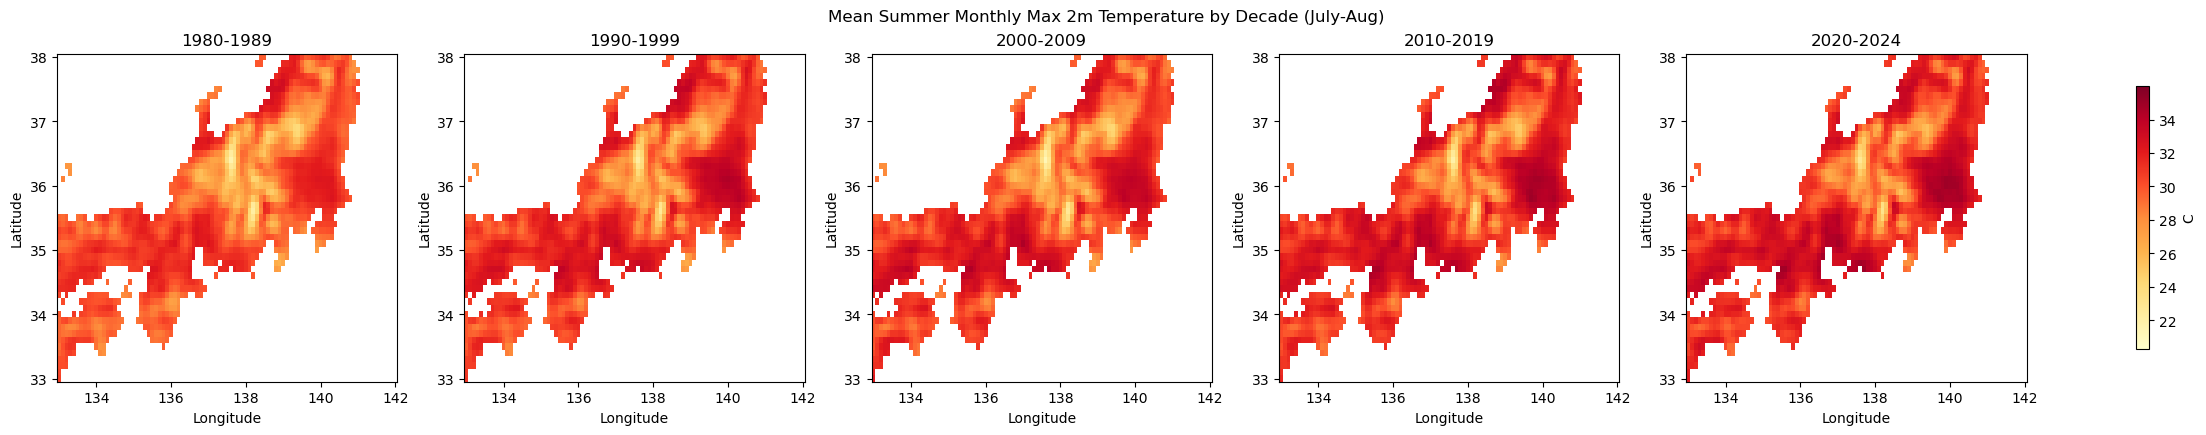

In [10]:
import matplotlib.pyplot as plt
import numpy as np

summer_mask = max_monthly_temp["valid_time"].dt.month.isin([7, 8])
summer_monthly_max = max_monthly_temp.sel(valid_time=summer_mask)

decade_means = {}
for label, (ys, ye) in DECADES.items():
    mask = (summer_monthly_max["valid_time"].dt.year >= ys) & (summer_monthly_max["valid_time"].dt.year <= ye)
    decade_means[label] = summer_monthly_max.sel(valid_time=mask).mean(dim="valid_time")

# Shared color scale across all panels
all_vals = np.concatenate([da.values.ravel() for da in decade_means.values()])
vmin, vmax = np.nanmin(all_vals), np.nanmax(all_vals)

fig, axes = plt.subplots(1, 5, figsize=(22, 4), constrained_layout=True)
for ax, (label, da) in zip(axes, decade_means.items()):
    im = da.plot(ax=ax, vmin=vmin - 1, vmax=vmax + 1, add_colorbar=False, cmap="YlOrRd")
    ax.set_title(label)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

fig.colorbar(im, ax=axes.tolist(), label="C", shrink=0.8)
fig.suptitle("Mean Summer Monthly Max 2m Temperature by Decade (July-Aug)", y=1.05)
savefig(fig, section=1, fig_num=1, title="mean_summer_monthly_max_t2m")
plt.show()

**Observation:** Consistent regional warming across all five decades, most pronounced over the interior mountain terrain west of Kanto. The Kanto plain itself (east side of the domain) intensifies noticeably by 2020–2024. *(First-pass narration — revisit with more targeted plots in a later pass.)*

## 2. Change in Mean Summer Monthly-Max Temperature vs. 1980–1999 Baseline

Anomaly of each later decade against the combined 1980–1999 baseline mean, on a diverging, symmetric colour scale.

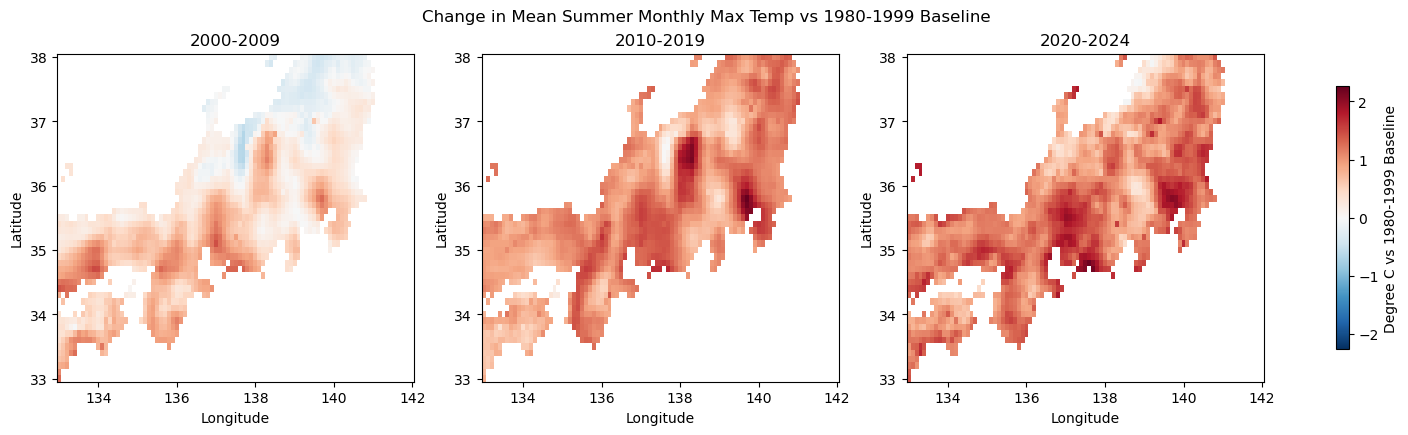

In [11]:
baseline_mask = summer_monthly_max["valid_time"].dt.year <= 1999
baseline = summer_monthly_max.sel(valid_time=baseline_mask).mean(dim="valid_time")

compare_periods = {k: v for k, v in DECADES.items() if k not in ("1980-1989", "1990-1999")}

anomalies = {}
for label, (ys, ye) in compare_periods.items():
    mask = (summer_monthly_max["valid_time"].dt.year >= ys) & (summer_monthly_max["valid_time"].dt.year <= ye)
    period_mean = summer_monthly_max.sel(valid_time=mask).mean(dim="valid_time")
    anomalies[label] = period_mean - baseline

# Symmetric scale around zero
all_vals = np.concatenate([da.values.ravel() for da in anomalies.values()])
vlim = np.nanmax(np.abs(all_vals))

fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
for ax, (label, da) in zip(axes, anomalies.items()):
    im = da.plot(ax=ax, vmin=-vlim, vmax=vlim, add_colorbar=False, cmap="RdBu_r")
    ax.set_title(label)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

fig.colorbar(im, ax=axes.tolist(), label="Degree C vs 1980-1999 Baseline", shrink=0.8)
fig.suptitle("Change in Mean Summer Monthly Max Temp vs 1980-1999 Baseline", y=1.05)
savefig(fig, section=2, fig_num=1, title="change_mean_summer_monthly_max_temp")
plt.show()

**Observation:** Anomaly is near-zero (even slightly negative in the northeast) for 2000–2009, then a clear +0.5 to +1.5°C warming emerges by 2010–2019 and intensifies further by 2020–2024 (locally up to +2°C). Reads as an accelerating, non-linear warming trajectory rather than a steady linear trend — consistent with the committed GAM approach (CLAUDE.md: do not report a single linear trend across the full period).

## 3. Days of Extreme Heat (≥35°C)

Annual count of days with daily-max 2m temperature ≥35°C, restricted to the Jul–Sep heat wave season (CLAUDE.md-committed window — matches the JMA-side computation in notebook 02 for like-for-like comparison in notebook 03), averaged within each decade. Uses `daily_tmax` from Data Processing above.

**Caveat:** ERA5-Land carries a cold bias that suppresses ≥35°C counts relative to JMA station observations — absolute counts here should not be read at face value; the spatial *trend* across decades is the reliable signal. See notebook 03 for the quantified bias.

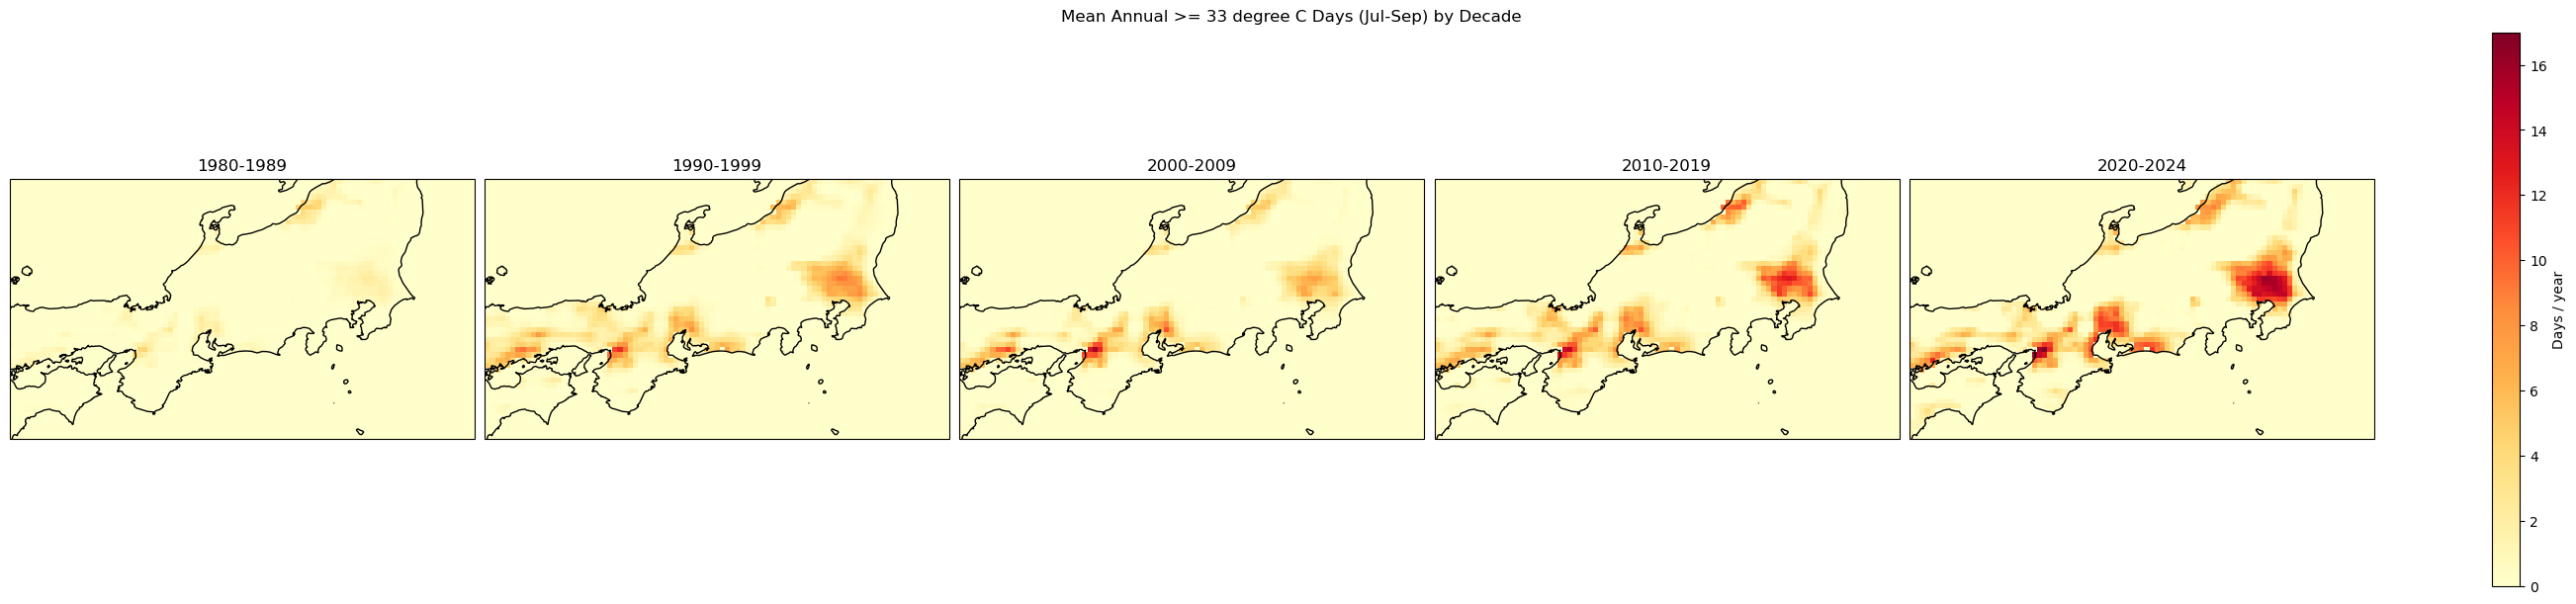

In [34]:
import cartopy.crs as ccrs

# Jul-Sep heat wave season (CLAUDE.md), not just Jul-Aug
season_tmax = daily_tmax.sel(valid_time=daily_tmax["valid_time"].dt.month.isin([7, 8, 9]))

temp_th = 33
hot_days = season_tmax >= temp_th
annual_hot_days = hot_days.resample(valid_time="1YE").sum()

decade_hot_days = {}
for label, (ys, ye) in DECADES.items():
    mask = (annual_hot_days["valid_time"].dt.year >= ys) & (annual_hot_days["valid_time"].dt.year <= ye)
    decade_hot_days[label] = annual_hot_days.sel(valid_time=mask).mean(dim="valid_time")

all_vals = np.concatenate([da.values.ravel() for da in decade_hot_days.values()])
vmin, vmax = np.nanmin(all_vals), np.nanmax(all_vals)

fig, axes = plt.subplots(
    1, 5, figsize=(26, 6), constrained_layout=True, subplot_kw={"projection": ccrs.PlateCarree()}
)
for ax, (label, da) in zip(axes, decade_hot_days.items()):
    im = da.plot(ax=ax, vmin=vmin, vmax=vmax, add_colorbar=False, cmap="YlOrRd", transform=ccrs.PlateCarree())
    ax.set_title(label)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.coastlines()

fig.colorbar(im, ax=axes.tolist(), label="Days / year")
fig.suptitle(f"Mean Annual >= {temp_th} degree C Days (Jul-Sep) by Decade")
savefig(fig, section=3, fig_num=1, title="mean_annual_plus35c_days_by_decade")
plt.show()

**Observation:** Absolute counts stay low (0–4 days/year even in 2020–2024) — expected given the ERA5-Land cold bias noted above. The spatial pattern does intensify over the study period: an inland hotspot persists across most decades, and a new coastal-Kanto cluster emerges by 2020–2024. The spatial trend, not the absolute count, is the reliable takeaway pending JMA cross-validation in notebook 03.

## 4. Tropical Nights (≥25°C Overnight Min)

Annual count of nights with daily-min 2m temperature ≥25°C, Jul–Sep, averaged within each decade. Uses `daily_tmin` from Data Processing above.

Unlike the ≥35°C hot-day counts, ERA5-Land's Tmin/tropical-night bias against JMA is small — both the counts and the trend here are trustworthy (see notebook 03).

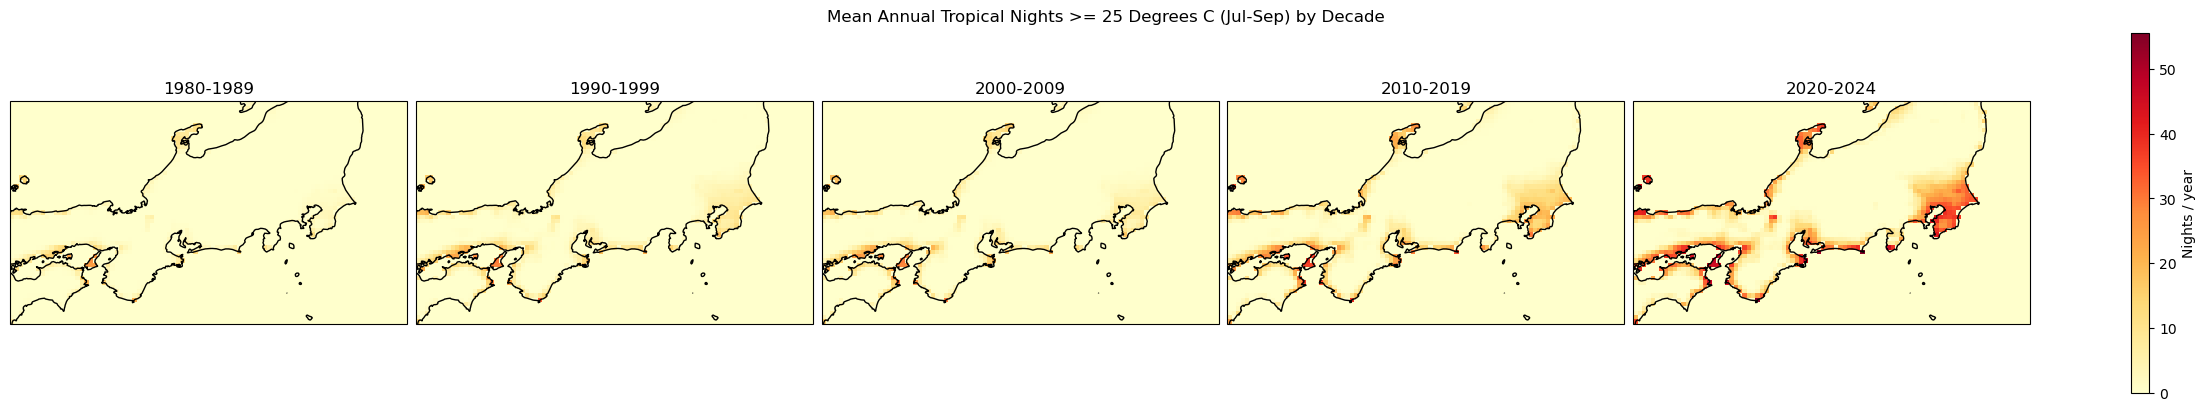

In [13]:
# Jul-Sep heat wave season (CLAUDE.md), not just Jul-Aug
season_tmin = daily_tmin.sel(valid_time=daily_tmin["valid_time"].dt.month.isin([7, 8, 9]))

annual_tropical_nights = (season_tmin >= 25).resample(valid_time="1YE").sum()

decade_tropical_nights = {}
for label, (ys, ye) in DECADES.items():
    mask = (annual_tropical_nights["valid_time"].dt.year >= ys) & (annual_tropical_nights["valid_time"].dt.year <= ye)
    decade_tropical_nights[label] = annual_tropical_nights.sel(valid_time=mask).mean(dim="valid_time")

all_vals = np.concatenate([da.values.ravel() for da in decade_tropical_nights.values()])
vmin, vmax = np.nanmin(all_vals), np.nanmax(all_vals)

fig, axes = plt.subplots(
    1, 5, figsize=(22, 4), constrained_layout=True, subplot_kw={"projection": ccrs.PlateCarree()}
)
for ax, (label, da) in zip(axes, decade_tropical_nights.items()):
    im = da.plot(ax=ax, vmin=vmin, vmax=vmax, add_colorbar=False, cmap="YlOrRd", transform=ccrs.PlateCarree())
    ax.set_title(label)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.coastlines()

fig.colorbar(im, ax=axes.tolist(), label="Nights / year")
fig.suptitle("Mean Annual Tropical Nights >= 25 Degrees C (Jul-Sep) by Decade")
savefig(fig, section=4, fig_num=1, title="mean_annual_tropical_nights_by_decade")
plt.show()

**Observation:** A much stronger, more spatially coherent signal than the ≥35°C counts: tropical nights are rare before 2000, expand steadily through the 2010s, and jump sharply in 2020–2024 to 30–50+ nights/year concentrated over the Kanto plain. Given ERA5-Land's small Tmin bias, this is likely the most trustworthy trend signal in this notebook.

## 5. Baiu-Season Precipitation

Baiu season is defined as June 1–July 31 (CLAUDE.md). Uses `daily_tp` from Data Processing above.

**Data note:** ERA5-Land `tp` is a GRIB "accum" field — each hourly value is the cumulative total since the forecast's last reset at 00 UTC, not that hour's individual rainfall. The setup cell de-accumulates this (differencing consecutive UTC hours, using the 00 UTC value itself at the reset point) *before* the JST shift, since the reset boundary is anchored to UTC, not JST. Summing the raw accumulated field directly (an earlier version of this notebook did this) inflates daily totals by roughly an order of magnitude — caught by comparing against JMA Tokyo climatological normals during this notebook's build.

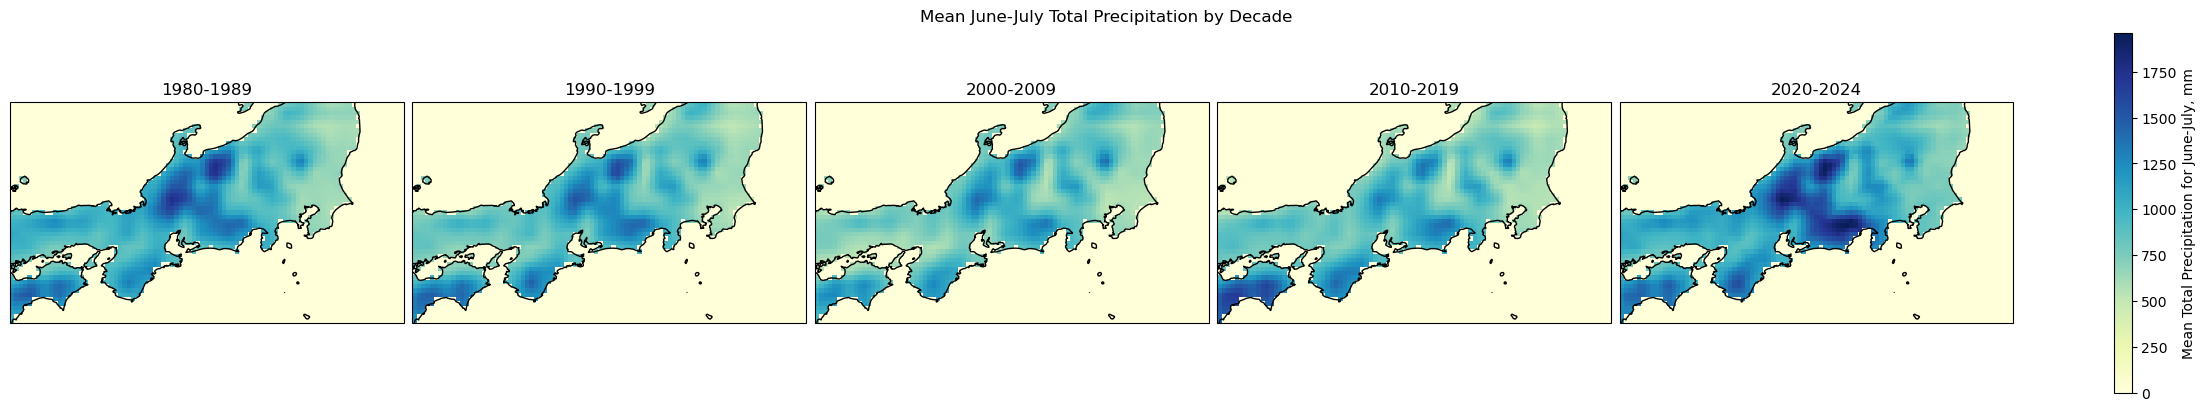

In [14]:
# YlGnBu confirmed against the rendered figure -- reads more intuitively as "wetness" than PuBu.
PRECIP_CMAP = "YlGnBu"

june_july_tp = daily_tp.sel(valid_time=daily_tp["valid_time"].dt.month.isin([6, 7]))
annual_june_july_tp = june_july_tp.resample(valid_time="1YS").sum()

decade_jj_precip = {}
for label, (ys, ye) in DECADES.items():
    mask = (annual_june_july_tp["valid_time"].dt.year >= ys) & (annual_june_july_tp["valid_time"].dt.year <= ye)
    decade_jj_precip[label] = annual_june_july_tp.sel(valid_time=mask).mean(dim="valid_time")

all_vals = np.concatenate([da.values.ravel() for da in decade_jj_precip.values()])
vmin, vmax = np.nanmin(all_vals), np.nanmax(all_vals)

fig, axes = plt.subplots(
    1, 5, figsize=(22, 4), constrained_layout=True, subplot_kw={"projection": ccrs.PlateCarree()}
)
for ax, (label, da) in zip(axes, decade_jj_precip.items()):
    im = da.plot(ax=ax, vmin=vmin, vmax=vmax, add_colorbar=False, cmap=PRECIP_CMAP, transform=ccrs.PlateCarree())
    ax.set_title(label)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.coastlines()

fig.colorbar(im, ax=axes.tolist(), label="Mean Total Precipitation for June-July, mm")
fig.suptitle("Mean June-July Total Precipitation by Decade")
savefig(fig, section=5, fig_num=1, title="mean_jj_monthly_tp_by_decade")
plt.show()

**Observation:** Totals are dominated by orographic effects over the western mountains (up to ~1800mm); the lower-lying Kanto plain is noticeably drier (~500–750mm). The decade-to-decade pattern is fairly stable with only a slight darkening near Kanto by 2020–2024 — consistent with the note below that the raw total is a noisy signal.

The overall June–July total is noisy and the decadal trend is not obvious. Precipitation is heavily right-skewed, so the mean is dominated by a handful of extreme days — looking at the distributional tail (R95p: sum of precip on days exceeding the per-cell 95th percentile) isolates the Baiu *intensity* signal more clearly than the raw total.

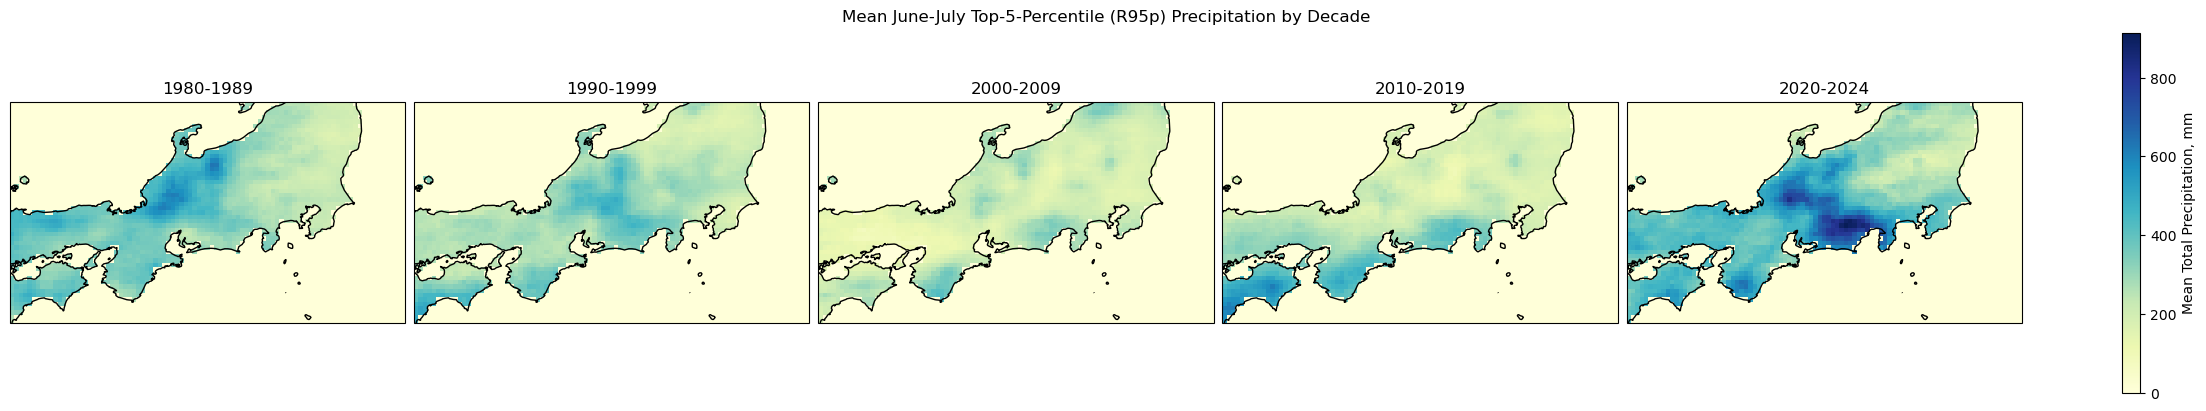

In [15]:
# 95th-percentile threshold per grid cell, across all June-July days in the record
tp_threshold_95 = june_july_tp.quantile(0.95, dim="valid_time").compute()

# Sum of precip on days exceeding that per-cell threshold, per year
heavy_rain_days = june_july_tp.where(june_july_tp > tp_threshold_95)
annual_r95p = heavy_rain_days.resample(valid_time="1YS").sum()

decade_jj_r95p_precip = {}
for label, (ys, ye) in DECADES.items():
    mask = (annual_r95p["valid_time"].dt.year >= ys) & (annual_r95p["valid_time"].dt.year <= ye)
    decade_jj_r95p_precip[label] = annual_r95p.sel(valid_time=mask).mean(dim="valid_time")

all_vals = np.concatenate([da.values.ravel() for da in decade_jj_r95p_precip.values()])
vmin, vmax = np.nanmin(all_vals), np.nanmax(all_vals)

fig, axes = plt.subplots(
    1, 5, figsize=(22, 4), constrained_layout=True, subplot_kw={"projection": ccrs.PlateCarree()}
)
for ax, (label, da) in zip(axes, decade_jj_r95p_precip.items()):
    im = da.plot(ax=ax, vmin=vmin, vmax=vmax, add_colorbar=False, cmap=PRECIP_CMAP, transform=ccrs.PlateCarree())
    ax.set_title(label)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.coastlines()

fig.colorbar(im, ax=axes.tolist(), label="Mean Total Precipitation, mm")
fig.suptitle("Mean June-July Top-5-Percentile (R95p) Precipitation by Decade")
savefig(fig, section=5, fig_num=2, title="mean_jj_monthly_r95p_tp_by_decade")
plt.show()

**Observation:** The sharpest, cleanest decadal signal in this notebook. 2020–2024 shows a pronounced intensification centered over inland Kanto (approaching 800–900mm, roughly double the 1980–2010 range at the same location), while the earlier decades stay comparatively flat and uniform. This is the strongest visual evidence for RQ2 (Baiu intensity) here — but the 2020–2024 bin is only 5 years wide and could be dominated by 2024 as a single outlier year (see the decade-bin caveat in Setup). Needs the GAM/bootstrap statistical treatment, not this decade-mean map, before it's reportable as a real trend.

### Preview (unnumbered, scratch): June vs. July Split

The combined June–July total obscures *when within* the Baiu window rain falls. Splitting June from July is a cheap way to preview whether an earlier Baiu termination (RQ2) is visible at this coarse decade resolution — reusing the caches and decade-binning machinery already built above. This is a scratch preview, not a polished section: if the signal looks real, it belongs in a dedicated RQ2 analysis notebook with proper statistical treatment, not here.

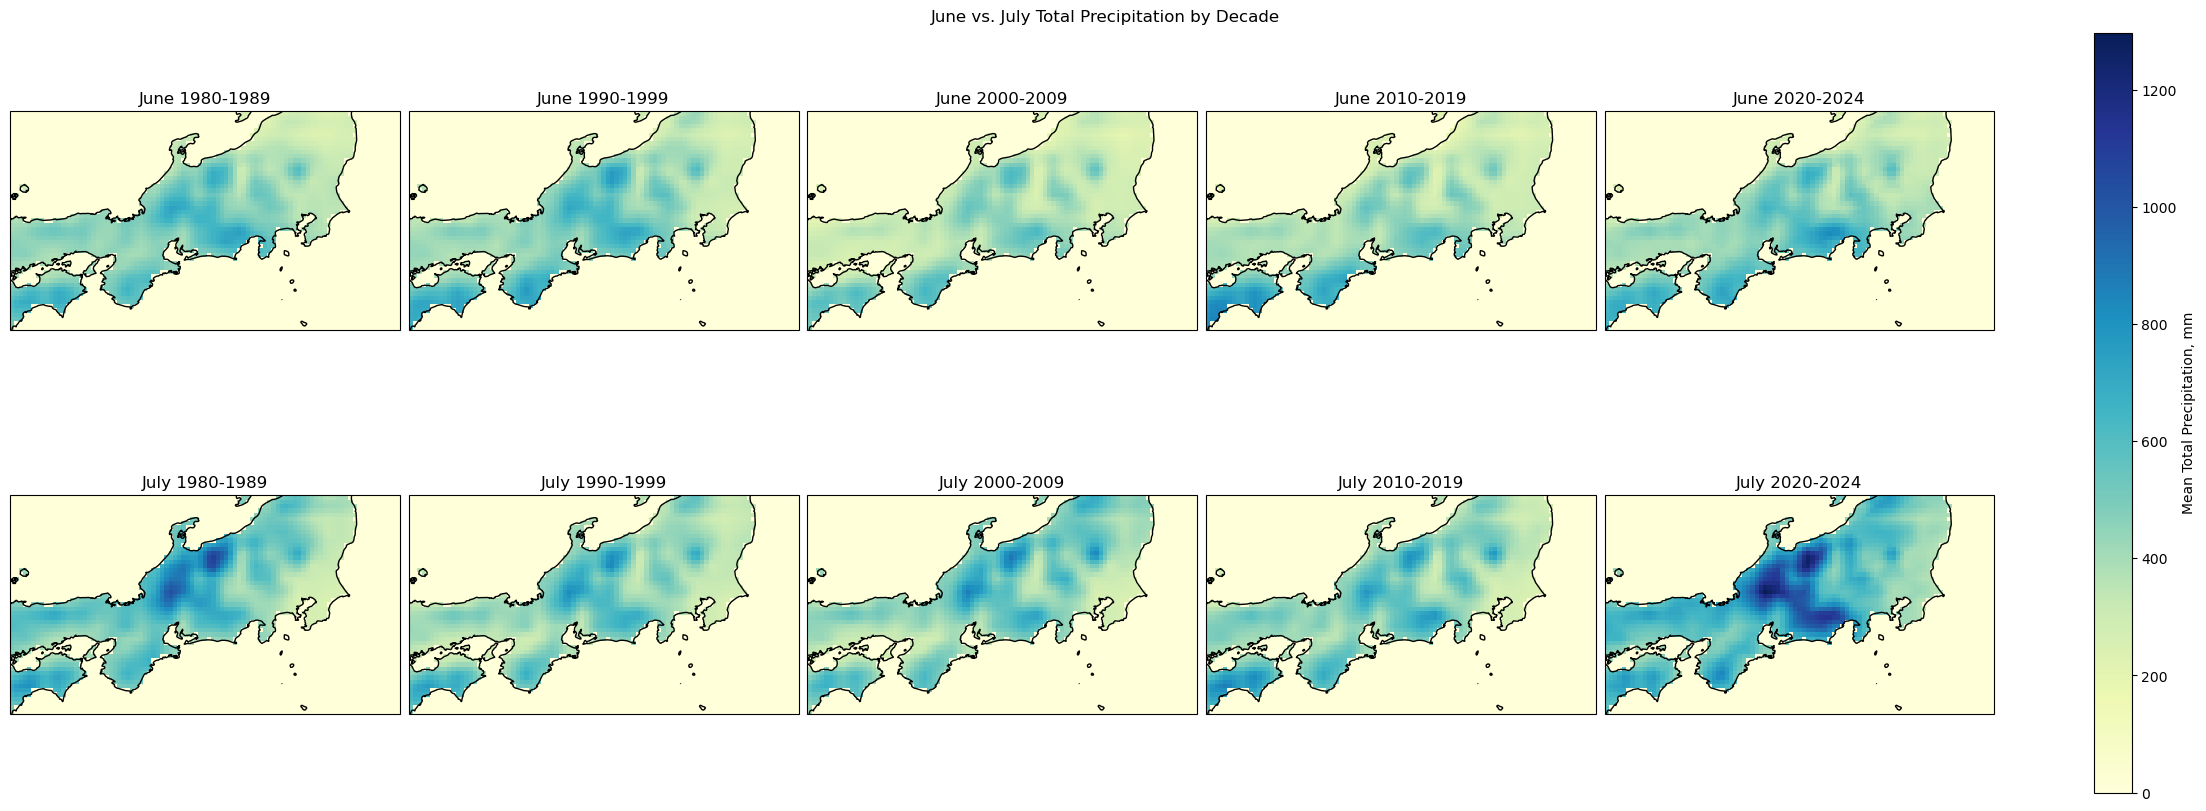

In [16]:
june_tp = daily_tp.sel(valid_time=daily_tp["valid_time"].dt.month == 6)
july_tp = daily_tp.sel(valid_time=daily_tp["valid_time"].dt.month == 7)

annual_june_tp = june_tp.resample(valid_time="1YS").sum()
annual_july_tp = july_tp.resample(valid_time="1YS").sum()

decade_june_precip, decade_july_precip = {}, {}
for label, (ys, ye) in DECADES.items():
    june_mask = (annual_june_tp["valid_time"].dt.year >= ys) & (annual_june_tp["valid_time"].dt.year <= ye)
    july_mask = (annual_july_tp["valid_time"].dt.year >= ys) & (annual_july_tp["valid_time"].dt.year <= ye)
    decade_june_precip[label] = annual_june_tp.sel(valid_time=june_mask).mean(dim="valid_time")
    decade_july_precip[label] = annual_july_tp.sel(valid_time=july_mask).mean(dim="valid_time")

all_vals = np.concatenate(
    [da.values.ravel() for da in list(decade_june_precip.values()) + list(decade_july_precip.values())]
)
vmin, vmax = np.nanmin(all_vals), np.nanmax(all_vals)

fig, axes = plt.subplots(
    2, 5, figsize=(22, 8), constrained_layout=True, subplot_kw={"projection": ccrs.PlateCarree()}
)
for ax, (label, da) in zip(axes[0], decade_june_precip.items()):
    im = da.plot(ax=ax, vmin=vmin, vmax=vmax, add_colorbar=False, cmap=PRECIP_CMAP, transform=ccrs.PlateCarree())
    ax.set_title(f"June {label}")
    ax.coastlines()
for ax, (label, da) in zip(axes[1], decade_july_precip.items()):
    im = da.plot(ax=ax, vmin=vmin, vmax=vmax, add_colorbar=False, cmap=PRECIP_CMAP, transform=ccrs.PlateCarree())
    ax.set_title(f"July {label}")
    ax.coastlines()

fig.colorbar(im, ax=axes.ravel().tolist(), label="Mean Total Precipitation, mm")
fig.suptitle("June vs. July Total Precipitation by Decade")
savefig(fig, section=5, fig_num=3, title="june_vs_july_split_precip_by_decade")
plt.show()

**Observation:** June totals look comparatively flat across decades; July shows a much larger swing, and its 2020–2024 peak sits at a similar inland location to a comparably wet patch already visible in 1980–1989 — not a monotonic trend, consistent with CLAUDE.md's expectation of a non-monotonic Baiu trajectory. Tentatively, intensity looks concentrated later in the Baiu window (July over June) in the most recent decade, which would be consistent with the RQ2 hypothesis of a shifting/later-intensifying Baiu season — but this is a coarse decade-mean preview, not a statistical claim; it belongs in the dedicated RQ2 notebook to confirm properly.

## 6. Kanto-Area Annual Time Series

The maps above show *where* change is concentrated; this section reduces each metric to a single Kanto-area annual value — a spatial mean over the bbox defined in Setup (`kanto_mean`, unweighted `nanmean` skipping ocean/bay cells) — rather than a decade snapshot. This is the natural precursor to the RQ1–RQ3 trend tests (Mann-Kendall, Pettitt, GAM), which need an annual scalar series, not a full grid or a 5-point decade average.

Reuses the arrays already computed in sections 1–5 (`summer_monthly_max`, `annual_hot_days`, `annual_tropical_nights`, `annual_june_july_tp`, `annual_r95p`) — no recomputation. The dashed line is a 5-year rolling mean shown purely as a visual aid; it is **not** a fitted trend and carries no statistical claim (that's the job of the GAM in the RQ1–RQ3 notebook).

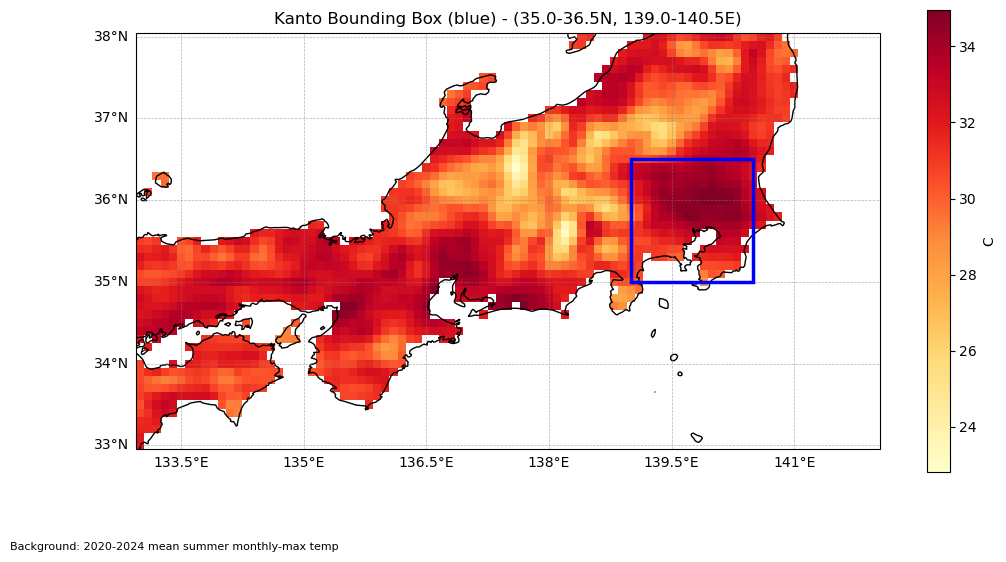

In [17]:
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(12, 6), subplot_kw={"projection": ccrs.PlateCarree()})
decade_means["2020-2024"].plot(
    ax=ax, cmap="YlOrRd", add_colorbar=True, cbar_kwargs={"label": "C", "shrink": 1.0}, transform=ccrs.PlateCarree()
)
ax.coastlines()
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color="gray", alpha=0.6, linestyle="--")
gl.top_labels = False
gl.right_labels = False
ax.add_patch(
    mpatches.Rectangle(
        (KANTO_LON_MIN, KANTO_LAT_MIN),
        KANTO_LON_MAX - KANTO_LON_MIN,
        KANTO_LAT_MAX - KANTO_LAT_MIN,
        fill=False,
        edgecolor="blue",
        linewidth=2.5,
        transform=ccrs.PlateCarree(),
        zorder=5,
    )
)
ax.set_title(f"Kanto Bounding Box (blue) - ({KANTO_LAT_MIN}-{KANTO_LAT_MAX}N, {KANTO_LON_MIN}-{KANTO_LON_MAX}E)", fontsize=12)
fig.text(0.02, -0.02, "Background: 2020-2024 mean summer monthly-max temp", fontsize=8, ha="left")
savefig(fig, section=6, fig_num=1, title="kanto_bbox_map")
plt.show()

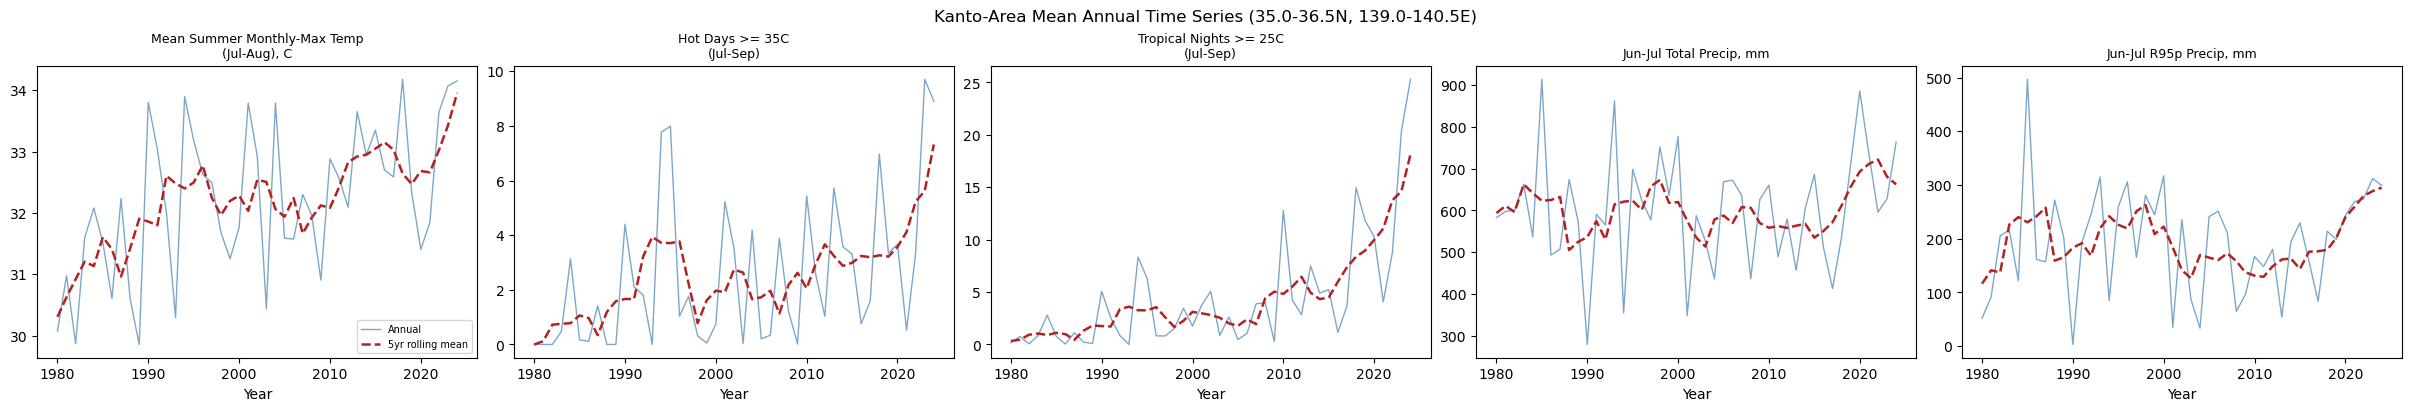

In [18]:
kanto_temp_ts = kanto_mean(summer_monthly_max).groupby("valid_time.year").mean()
kanto_hot_days_ts = kanto_mean(annual_hot_days)
kanto_tropical_nights_ts = kanto_mean(annual_tropical_nights)
kanto_precip_ts = kanto_mean(annual_june_july_tp)
kanto_r95p_ts = kanto_mean(annual_r95p)

series = {
    "Mean Summer Monthly-Max Temp\n(Jul-Aug), C": (kanto_temp_ts["year"].values, kanto_temp_ts.values),
    "Hot Days >= 35C\n(Jul-Sep)": (kanto_hot_days_ts["valid_time"].dt.year.values, kanto_hot_days_ts.values),
    "Tropical Nights >= 25C\n(Jul-Sep)": (
        kanto_tropical_nights_ts["valid_time"].dt.year.values,
        kanto_tropical_nights_ts.values,
    ),
    "Jun-Jul Total Precip, mm": (kanto_precip_ts["valid_time"].dt.year.values, kanto_precip_ts.values),
    "Jun-Jul R95p Precip, mm": (kanto_r95p_ts["valid_time"].dt.year.values, kanto_r95p_ts.values),
}

fig, axes = plt.subplots(1, 5, figsize=(24, 4), constrained_layout=True)
for ax, (title, (years, values)) in zip(axes, series.items()):
    ax.plot(years, values, color="steelblue", linewidth=1, alpha=0.7, label="Annual")
    rolling = pd.Series(values, index=years).rolling(5, center=True, min_periods=3).mean()
    ax.plot(years, rolling.values, color="firebrick", linewidth=1.8, linestyle="--", label="5yr rolling mean")
    ax.set_title(title, fontsize=9)
    ax.set_xlabel("Year")

axes[0].legend(fontsize=7)
fig.suptitle(
    f"Kanto-Area Mean Annual Time Series "
    f"({KANTO_LAT_MIN}-{KANTO_LAT_MAX}N, {KANTO_LON_MIN}-{KANTO_LON_MAX}E)"
)
savefig(fig, section=6, fig_num=2, title="kanto_area_mean_annual_timeseries")
plt.show()

**Observation:** The area-mean series make the map-based signals concrete. Mean summer monthly-max temp rises fairly steadily from ~30°C (1980) to ~34°C (2024). Hot-day and tropical-night counts are much noisier year-to-year (as expected for threshold-crossing counts) but both trend upward, with tropical nights showing the clearest acceleration — a jump to 25 nights in 2024 alone, well above the rolling mean. Precip totals stay noisy with no obvious visual trend, but R95p shows a steadier rise from the 2000s onward, reinforcing that the *intensity* tail, not the raw total, carries the clearer Baiu signal. None of this is a fitted trend (no significance testing here) — but it's a much more direct precursor to the RQ1–RQ3 Mann-Kendall/Pettitt/GAM work than the decade-snapshot maps above.

**On the hot-side wiggle:** beyond the long-term rise, the temp and hot-days panels show what looks like recurring peaks every ~4-8 years (e.g. the 1994 spike, a known historic Japan heatwave year). Plausible candidates are ENSO (already a committed RQ3 covariate via Niño 3.4) or the 2002/2003 jet regime shift CLAUDE.md flags as a structural break — but with only 45 annual points this could just as easily be natural interannual noise. Flagged here as a hypothesis, not a claim; distinguishing signal from noise needs the Pettitt break test and/or an ENSO correlation in the RQ1/RQ3 statistical notebook, not eyeballing this plot.

### Breakout: Monthly-Max Temp by Individual Month (Jun-Sep)

The panel above averages July+August together, which can mask whether warming is uniform across the season or concentrated in specific months. Reusing `max_monthly_temp` (already cached with all 12 months, not just the Jul-Aug summer filter used in Section 1) — no recomputation, just re-filtered per month.

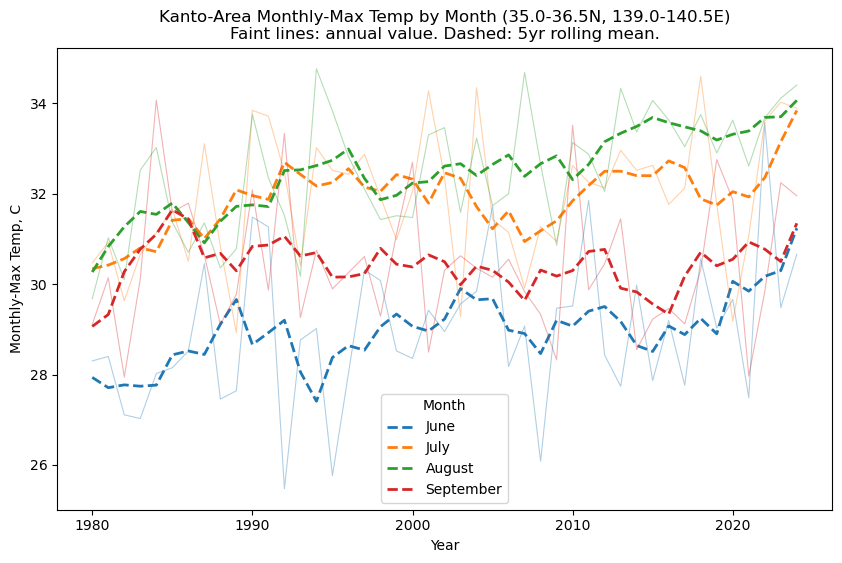

In [19]:
MONTH_NAMES = {6: "June", 7: "July", 8: "August", 9: "September"}
MONTH_COLORS = {6: "tab:blue", 7: "tab:orange", 8: "tab:green", 9: "tab:red"}

fig, ax = plt.subplots(figsize=(10, 6))
for month, name in MONTH_NAMES.items():
    month_max = max_monthly_temp.sel(valid_time=max_monthly_temp["valid_time"].dt.month == month)
    kanto_month_ts = kanto_mean(month_max)
    years = kanto_month_ts["valid_time"].dt.year.values
    values = kanto_month_ts.values
    color = MONTH_COLORS[month]

    ax.plot(years, values, color=color, linewidth=0.8, alpha=0.35)
    rolling = pd.Series(values, index=years).rolling(5, center=True, min_periods=3).mean()
    ax.plot(years, rolling.values, color=color, linewidth=2, linestyle="--", label=name)

ax.set_xlabel("Year")
ax.set_ylabel("Monthly-Max Temp, C")
ax.set_title(
    f"Kanto-Area Monthly-Max Temp by Month "
    f"({KANTO_LAT_MIN}-{KANTO_LAT_MAX}N, {KANTO_LON_MIN}-{KANTO_LON_MAX}E)\n"
    "Faint lines: annual value. Dashed: 5yr rolling mean."
)
ax.legend(title="Month")
savefig(fig, section=6, fig_num=3, title="kanto_monthly_max_temp_by_month")
plt.show()

### Breakout: All 12 Months

Extending to the full year. With 12 series, overlaying both raw + rolling (as above) would be unreadable — showing only the 5yr rolling mean, colored on a cold-to-hot gradient by calendar month. Lets us check whether winter months are warming at a different rate than summer, not just describe the Jun-Sep heat wave season.

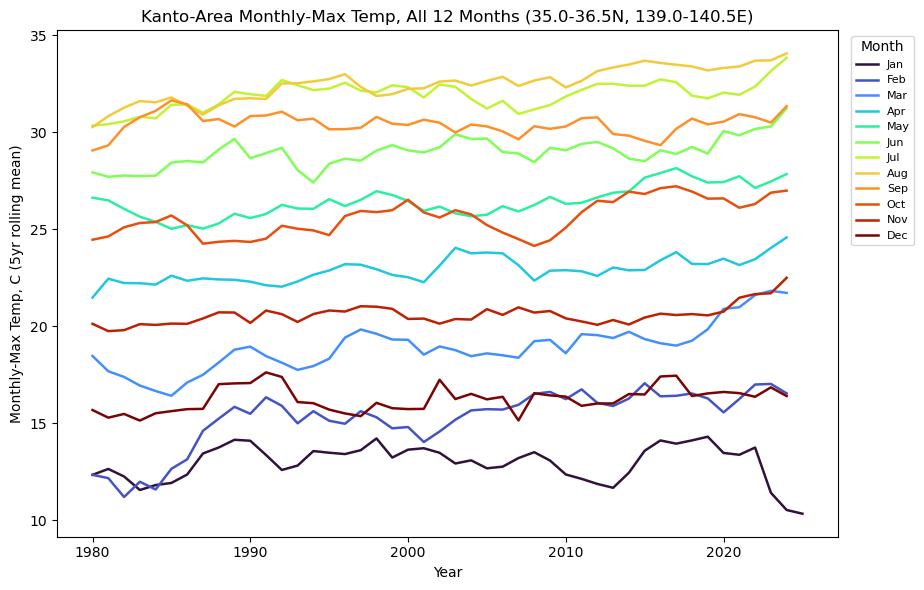

In [20]:
ALL_MONTHS = list(range(1, 13))
MONTH_LABELS = {
    1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr", 5: "May", 6: "Jun",
    7: "Jul", 8: "Aug", 9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec",
}
month_cmap = plt.cm.turbo
month_colors = {m: month_cmap(i / 11) for i, m in enumerate(ALL_MONTHS)}

fig, ax = plt.subplots(figsize=(11, 6))
for month in ALL_MONTHS:
    month_max = max_monthly_temp.sel(valid_time=max_monthly_temp["valid_time"].dt.month == month)
    kanto_month_ts = kanto_mean(month_max)
    years = kanto_month_ts["valid_time"].dt.year.values
    values = kanto_month_ts.values
    rolling = pd.Series(values, index=years).rolling(5, center=True, min_periods=3).mean()
    ax.plot(years, rolling.values, color=month_colors[month], linewidth=1.8, label=MONTH_LABELS[month])

ax.set_xlabel("Year")
ax.set_ylabel("Monthly-Max Temp, C (5yr rolling mean)")
ax.set_title(
    f"Kanto-Area Monthly-Max Temp, All 12 Months "
    f"({KANTO_LAT_MIN}-{KANTO_LAT_MAX}N, {KANTO_LON_MIN}-{KANTO_LON_MAX}E)"
)
ax.legend(title="Month", ncol=1, fontsize=8, loc="upper left", bbox_to_anchor=(1.01, 1))
fig.tight_layout(rect=[0, 0, 0.85, 1])
savefig(fig, section=6, fig_num=4, title="kanto_monthly_max_temp_all_months")
plt.show()

### Breakout: Mean vs. Max vs. Min Temp

Everything above uses monthly-*max* temperature — the hottest single hourly reading each month. That describes the extreme hot tail, not whether the whole season is warming. Using the `mean_monthly_temp` and `min_monthly_temp` caches to compute the same Kanto-area Jul-Aug series and plotting all three together on the same axes: if all three are rising at similar rates, warming is fairly uniform across the distribution; if max is pulling away from mean/min, hot extremes are outpacing the average; if min is rising fastest, the cold tail (overnight/early-morning lows) is compressing toward the mean faster than the hot tail is extending past it — a distinct and separately meaningful signal from the ≥25°C tropical-night counts in Section 4 (which are a threshold count, not a magnitude trend).

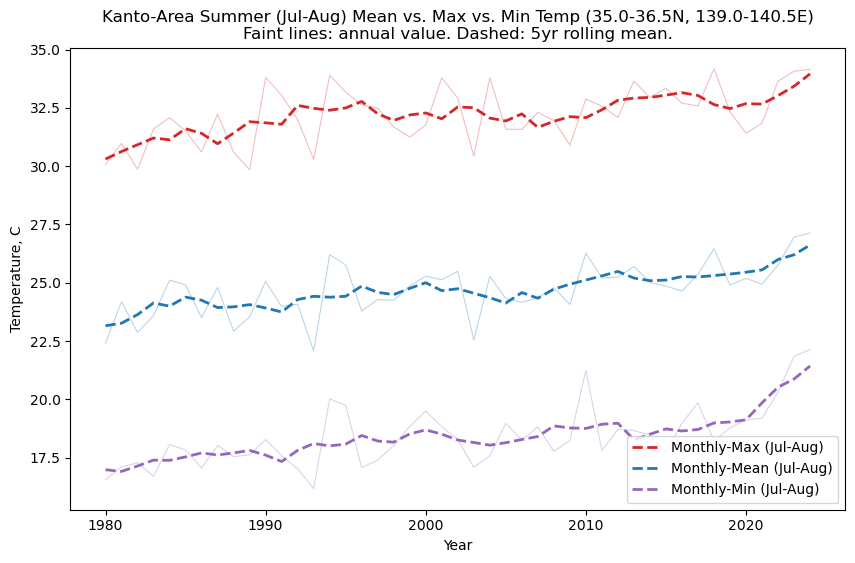

In [21]:
summer_monthly_mean = mean_monthly_temp.sel(valid_time=mean_monthly_temp["valid_time"].dt.month.isin([7, 8]))
summer_monthly_min = min_monthly_temp.sel(valid_time=min_monthly_temp["valid_time"].dt.month.isin([7, 8]))
kanto_mean_temp_ts = kanto_mean(summer_monthly_mean).groupby("valid_time.year").mean()
kanto_min_temp_ts = kanto_mean(summer_monthly_min).groupby("valid_time.year").mean()

fig, ax = plt.subplots(figsize=(10, 6))
for label, ts, color in [
    ("Monthly-Max (Jul-Aug)", kanto_temp_ts, "tab:red"),
    ("Monthly-Mean (Jul-Aug)", kanto_mean_temp_ts, "tab:blue"),
    ("Monthly-Min (Jul-Aug)", kanto_min_temp_ts, "tab:purple"),
]:
    years = ts["year"].values
    values = ts.values
    ax.plot(years, values, color=color, linewidth=0.8, alpha=0.3)
    rolling = pd.Series(values, index=years).rolling(5, center=True, min_periods=3).mean()
    ax.plot(years, rolling.values, color=color, linewidth=2, linestyle="--", label=label)

ax.set_xlabel("Year")
ax.set_ylabel("Temperature, C")
ax.set_title(
    f"Kanto-Area Summer (Jul-Aug) Mean vs. Max vs. Min Temp "
    f"({KANTO_LAT_MIN}-{KANTO_LAT_MAX}N, {KANTO_LON_MIN}-{KANTO_LON_MAX}E)\n"
    "Faint lines: annual value. Dashed: 5yr rolling mean."
)
ax.legend()
savefig(fig, section=6, fig_num=5, title="kanto_mean_vs_max_vs_min_temp")
plt.show()

**Observation:** All three series rise, but not at the same rate. Monthly-min tracks roughly flat through the 1980s-2010s (~17-19°C) then climbs sharply after 2020 to ~21-22°C, a steeper post-2020 slope than either monthly-max or monthly-mean show over the same window. Monthly-max and monthly-mean rise more steadily across the full record by comparison. This is consistent with (not necessarily caused by) the accelerating tropical-night counts already noted in Section 4 — both describe the cold tail (overnight/early-morning lows) compressing upward. As with the hot-side wiggle noted above, 45 annual points is a short record for distinguishing an accelerating trend from noise; this is flagged as an observation for the RQ1 statistical notebook (GAM, Mann-Kendall/Pettitt) to test formally, not a claim made here.

## 7. Kanto-Area Heat Calendar: Daily Max Temp by Day and Year

The time series above show *annual* trends but flatten each year to a handful of scalars (a mean, a threshold count). This section instead shows every individual day: one row per year (1980–2024), one column per calendar day from June 1–September 30, colored by that day's Kanto-area mean daily-max temperature (`kanto_mean(daily_tmax)`, same series as the rest of this notebook). This makes it possible to see not just *that* summers are getting hotter, but *when within the season* heat concentrates and whether hot stretches are lengthening — a timing signal the annual scalars above can't show.

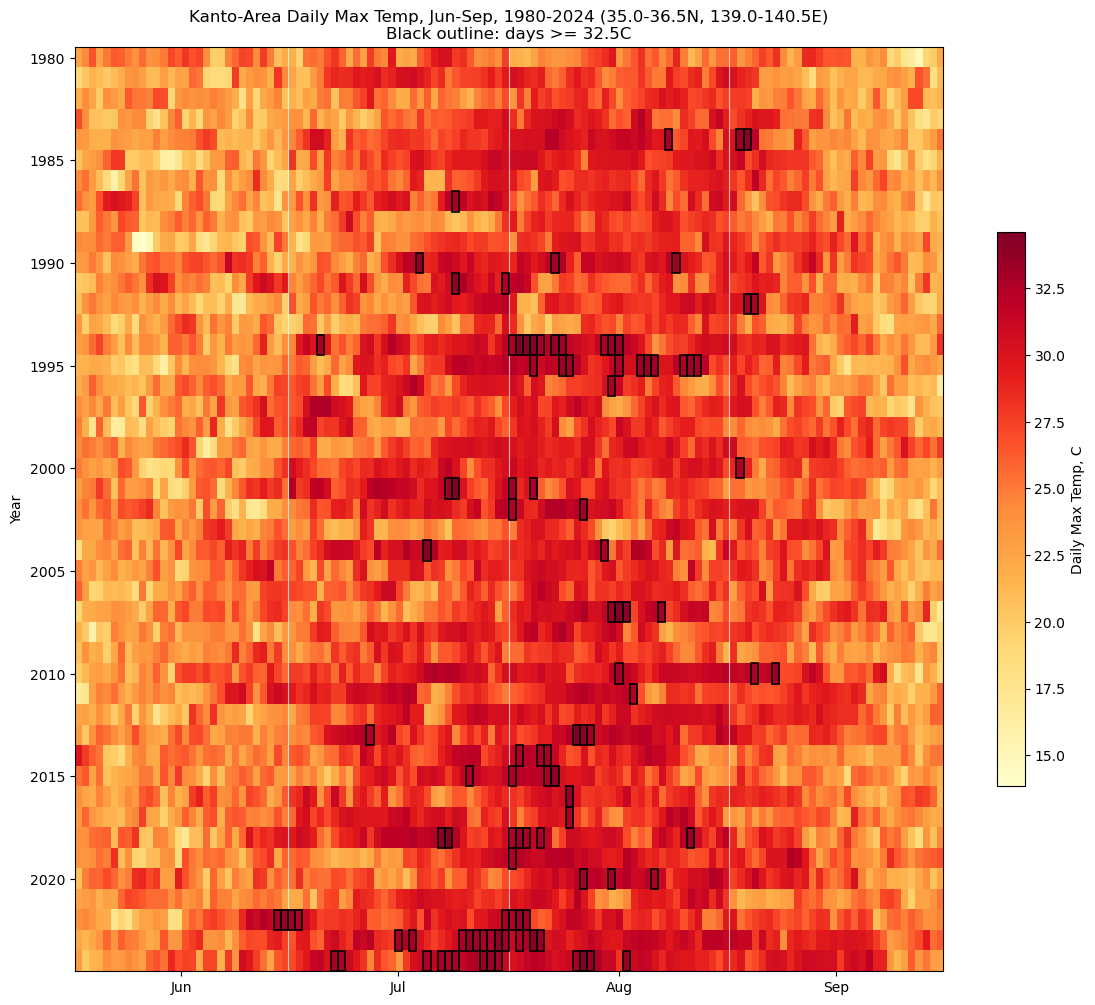

In [22]:
kanto_daily_tmax = kanto_mean(daily_tmax)
season_mask = kanto_daily_tmax["valid_time"].dt.month.isin([6, 7, 8, 9])
season_tmax_ts = kanto_daily_tmax.sel(valid_time=season_mask)

# Column index = days since June 1 within a Jun-Sep season. Jun-Sep never includes Feb 29,
# so this offset is identical for leap and non-leap years -- no calendar alignment issues.
MONTH_OFFSET = {6: 0, 7: 30, 8: 61, 9: 92}
N_DAYS = 122  # 30 (Jun) + 31 (Jul) + 31 (Aug) + 30 (Sep)

years = np.arange(1980, 2025)
months = season_tmax_ts["valid_time"].dt.month.values
days = season_tmax_ts["valid_time"].dt.day.values
obs_years = season_tmax_ts["valid_time"].dt.year.values

col_idx = np.array([MONTH_OFFSET[m] + (d - 1) for m, d in zip(months, days)])
row_idx = obs_years - years[0]

grid = np.full((len(years), N_DAYS), np.nan)
grid[row_idx, col_idx] = season_tmax_ts.values

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(grid, aspect="auto", cmap="YlOrRd", interpolation="nearest")

# Outline each day above certain threshold value
th_temp = 32.5
hot_rows, hot_cols = np.where(grid >= th_temp)
for r, c in zip(hot_rows, hot_cols):
    ax.add_patch(
        mpatches.Rectangle(
            (c - 0.5, r - 0.5), 1, 1, fill=False, edgecolor="black", linewidth=1.2, zorder=5
        )
    )

month_bounds = [0, 30, 61, 92, N_DAYS]
month_names = ["Jun", "Jul", "Aug", "Sep"]
ax.set_xticks([(month_bounds[i] + month_bounds[i + 1] - 1) / 2 for i in range(4)])
ax.set_xticklabels(month_names)
for x in month_bounds[1:-1]:
    ax.axvline(x - 0.5, color="white", linewidth=0.8, alpha=0.7)

ax.set_yticks(np.arange(0, len(years), 5))
ax.set_yticklabels(years[::5])
ax.set_ylabel("Year")
ax.set_title(
    f"Kanto-Area Daily Max Temp, Jun-Sep, 1980-2024 "
    f"({KANTO_LAT_MIN}-{KANTO_LAT_MAX}N, {KANTO_LON_MIN}-{KANTO_LON_MAX}E)\n"
    f"Black outline: days >= {th_temp}C"
)
fig.colorbar(im, ax=ax, label="Daily Max Temp, C", shrink=0.6)
savefig(fig, section=7, fig_num=1, title="kanto_daily_tmax_calendar_heatmap")
plt.show()

### Same Calendar, Daily Min Temp

Same grid layout as Fig 7-1 (rows = years, columns = Jun 1–Sep 30), now colored by Kanto-area mean daily-*min* temperature (`kanto_mean(daily_tmin)`) instead of daily-max. This is the daily-resolution analog of the annual tropical-night counts in Section 4: instead of one count per year, it shows *when within the season* overnight lows push into tropical-night territory and whether that window is widening. Outline threshold defaults to 25°C — the Section 4 tropical-night threshold, a separate `th_temp_min` variable from the max-temp `th_temp` above so the two plots can be tuned independently.

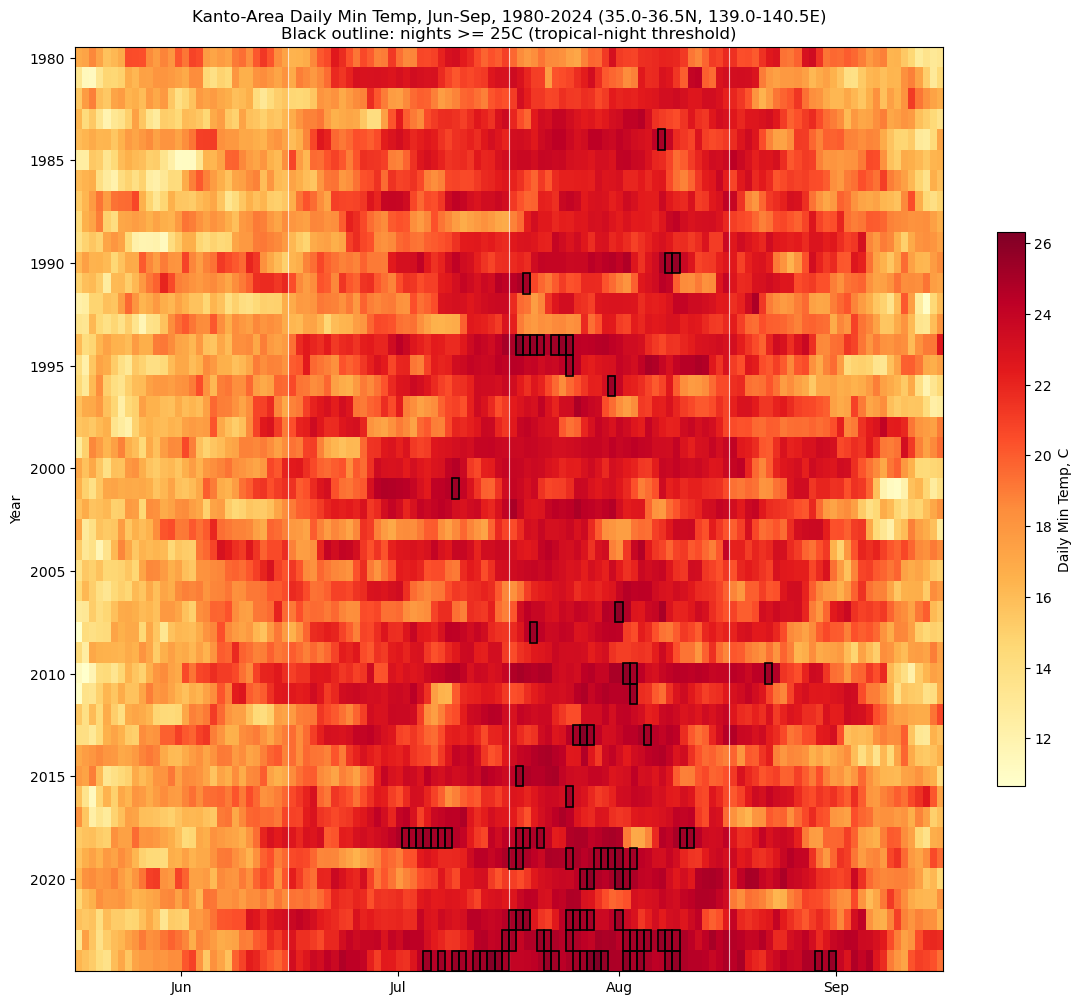

In [23]:
kanto_daily_tmin = kanto_mean(daily_tmin)
tmin_season_ts = kanto_daily_tmin.sel(valid_time=kanto_daily_tmin["valid_time"].dt.month.isin([6, 7, 8, 9]))

tmin_months = tmin_season_ts["valid_time"].dt.month.values
tmin_days = tmin_season_ts["valid_time"].dt.day.values
tmin_obs_years = tmin_season_ts["valid_time"].dt.year.values

tmin_col_idx = np.array([MONTH_OFFSET[m] + (d - 1) for m, d in zip(tmin_months, tmin_days)])
tmin_row_idx = tmin_obs_years - years[0]

tmin_grid = np.full((len(years), N_DAYS), np.nan)
tmin_grid[tmin_row_idx, tmin_col_idx] = tmin_season_ts.values

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(tmin_grid, aspect="auto", cmap="YlOrRd", interpolation="nearest")

# Tropical-night threshold (Section 4) -- independent from the max-temp th_temp above
th_temp_min = 25
hot_rows, hot_cols = np.where(tmin_grid >= th_temp_min)
for r, c in zip(hot_rows, hot_cols):
    ax.add_patch(
        mpatches.Rectangle(
            (c - 0.5, r - 0.5), 1, 1, fill=False, edgecolor="black", linewidth=1.2, zorder=5
        )
    )

ax.set_xticks([(month_bounds[i] + month_bounds[i + 1] - 1) / 2 for i in range(4)])
ax.set_xticklabels(month_names)
for x in month_bounds[1:-1]:
    ax.axvline(x - 0.5, color="white", linewidth=0.8, alpha=0.7)

ax.set_yticks(np.arange(0, len(years), 5))
ax.set_yticklabels(years[::5])
ax.set_ylabel("Year")
ax.set_title(
    f"Kanto-Area Daily Min Temp, Jun-Sep, 1980-2024 "
    f"({KANTO_LAT_MIN}-{KANTO_LAT_MAX}N, {KANTO_LON_MIN}-{KANTO_LON_MAX}E)\n"
    f"Black outline: nights >= {th_temp_min}C (tropical-night threshold)"
)
fig.colorbar(im, ax=ax, label="Daily Min Temp, C", shrink=0.6)
savefig(fig, section=7, fig_num=2, title="kanto_daily_tmin_calendar_heatmap")
plt.show()

**Observation:** A much sharper timing/duration signal than Fig 7-1's hot-day highlight. Tropical-night crossings (black outline) are essentially absent before the mid-1990s, appear as scattered single-day events through the 2000s-2010s clustered around late July-early August, and then expand sharply after 2020 into dense, multi-day contiguous blocks spanning most of July and August in 2023-2024 -- with a couple of recent years even reaching into early September. This reads as the hot season's tropical-night window both intensifying and widening, not just becoming more frequent on average. Consistent with (not necessarily caused by) the Section 4 annual tropical-night acceleration and the Fig 6-5 finding that monthly-min is rising faster than monthly-max/mean since 2020 -- this calendar view makes that same signal visible day-by-day rather than as an annual count or scalar trend. As with the other hedged observations in this notebook, this is descriptive: whether the widening itself is an accelerating trend or falls within natural interannual variability over a 45-year record is a question for the RQ1 statistical notebook (GAM, Mann-Kendall/Pettitt), not a claim made here.

**Cross-figure note (Fig 7-1 vs 7-2):** the one early exception to the "clustering is a recent phenomenon" read is the 1994-1995 cluster in both figures -- the same historic heatwave already flagged as a possible outlier in Section 6 ("hot-side wiggle"). Setting that aside, the highlighted clusters in *both* the max-temp (Fig 7-1) and min-temp (Fig 7-2) calendars are clearly concentrated toward the bottom of the plot (recent years), not spread evenly across 1980-2024. That both the hot-day and tropical-night timing views independently show the same late-record concentration is a more consistent picture than either alone -- though, as above, 1994-95 is a reminder that at least one earlier isolated cluster exists and the record is still short enough that formal testing (Pettitt break test in particular) should confirm this is a genuine shift and not just recency looking more prominent by eye.

### Same Calendar, Daily Precipitation

A third calendar in the same style (rows = years, columns = Jun 1–Sep 30), now for daily total precipitation (`kanto_mean(daily_tp)`) instead of temperature. Daily precip is heavily right-skewed (Section 5: a handful of extreme days dominate any linear scale) — colored here on a `log10(mm + 0.1)` scale so ordinary rain days stay visually distinguishable instead of being washed out by the extremes. The `+0.1` offset avoids `log(0)` for dry days: they land at the palest end of the same continuous scale rather than needing a separate mask. Black outline highlights days at or above an adjustable `th_precip` threshold (heavy rain), same style as Figs 7-1/7-2.

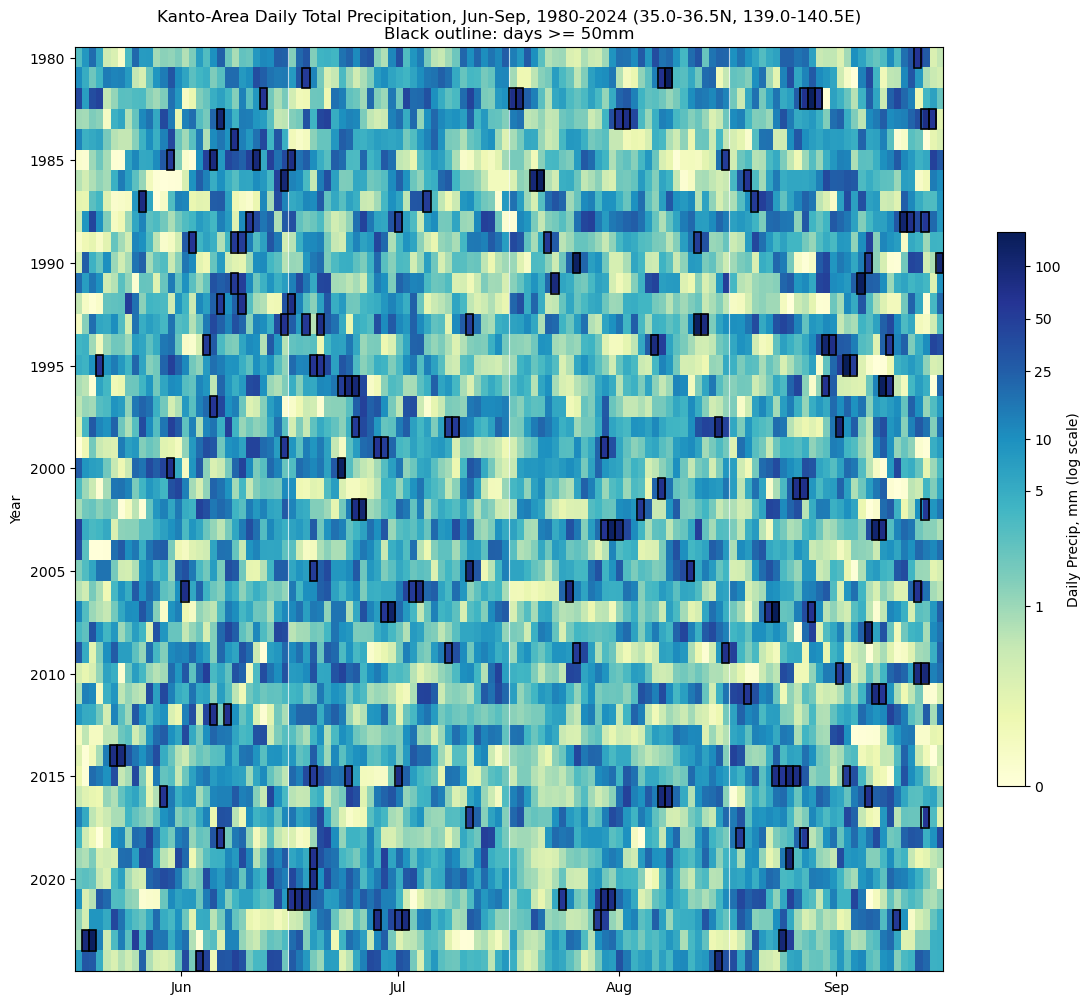

In [24]:
kanto_daily_tp = kanto_mean(daily_tp)
tp_season_ts = kanto_daily_tp.sel(valid_time=kanto_daily_tp["valid_time"].dt.month.isin([6, 7, 8, 9]))

tp_months = tp_season_ts["valid_time"].dt.month.values
tp_days = tp_season_ts["valid_time"].dt.day.values
tp_obs_years = tp_season_ts["valid_time"].dt.year.values

tp_col_idx = np.array([MONTH_OFFSET[m] + (d - 1) for m, d in zip(tp_months, tp_days)])
tp_row_idx = tp_obs_years - years[0]

tp_grid = np.full((len(years), N_DAYS), np.nan)
tp_grid[tp_row_idx, tp_col_idx] = tp_season_ts.values

# Log-scale color (+0.1mm offset avoids log(0)) -- keeps ordinary rain days distinguishable
# instead of a few extreme days washing out the rest of the palette. Dry days land at the
# palest end of the same scale rather than needing a separate mask.
log_tp_grid = np.log10(tp_grid + 0.1)

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(log_tp_grid, aspect="auto", cmap=PRECIP_CMAP, interpolation="nearest")

# Heavy-rain-day threshold, in raw mm (not log units) -- independent of th_temp/th_temp_min
th_precip = 50
hot_rows, hot_cols = np.where(tp_grid >= th_precip)
for r, c in zip(hot_rows, hot_cols):
    ax.add_patch(
        mpatches.Rectangle(
            (c - 0.5, r - 0.5), 1, 1, fill=False, edgecolor="black", linewidth=1.2, zorder=5
        )
    )

ax.set_xticks([(month_bounds[i] + month_bounds[i + 1] - 1) / 2 for i in range(4)])
ax.set_xticklabels(month_names)
for x in month_bounds[1:-1]:
    ax.axvline(x - 0.5, color="white", linewidth=0.8, alpha=0.7)

ax.set_yticks(np.arange(0, len(years), 5))
ax.set_yticklabels(years[::5])
ax.set_ylabel("Year")
ax.set_title(
    f"Kanto-Area Daily Total Precipitation, Jun-Sep, 1980-2024 "
    f"({KANTO_LAT_MIN}-{KANTO_LAT_MAX}N, {KANTO_LON_MIN}-{KANTO_LON_MAX}E)\n"
    f"Black outline: days >= {th_precip}mm"
)

tick_vals_mm = [0, 1, 5, 10, 25, 50, 100]
cbar = fig.colorbar(im, ax=ax, label="Daily Precip, mm (log scale)", shrink=0.6)
cbar.set_ticks(np.log10(np.array(tick_vals_mm) + 0.1))
cbar.set_ticklabels([str(v) for v in tick_vals_mm])

savefig(fig, section=7, fig_num=3, title="kanto_daily_precip_calendar_heatmap")
plt.show()

### Same Calendar, 10-Day Rolling Precipitation Sum

The raw daily calendar above is dominated by single-day noise — consistent with Section 5's finding that daily/monthly precip totals are noisy with no clear decadal pattern by eye. This adds a second precipitation calendar (kept alongside the raw one, not replacing it) using a 10-day centered rolling *sum* per year instead of the raw daily value — smoothing single-day spikes into visible "wet spell" blocks, the same idea as the 5yr rolling mean used to smooth the annual time series elsewhere in this notebook. The rolling window is computed per year only (never crossing into the neighboring year's Jun–Sep window). Same log-color-scale and adjustable-threshold outline design as the raw calendar.

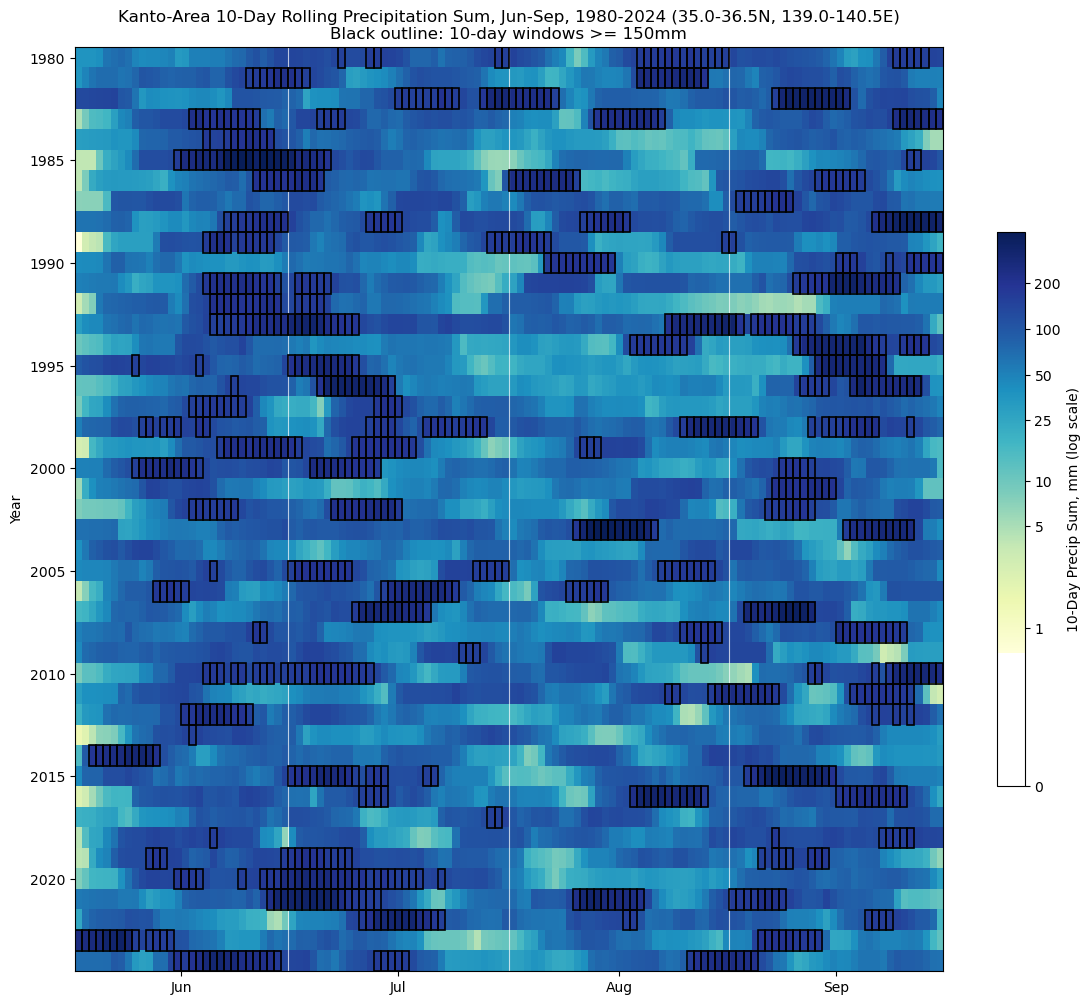

In [25]:
# 5-day centered rolling sum per year -- transposing so pandas rolls along the day axis
# within each year's column, never crossing into the neighboring year's Jun-Sep window
ROLL_WINDOW = 10
tp_rolled_grid = (
    pd.DataFrame(tp_grid.T)
    .rolling(window=ROLL_WINDOW, center=True, min_periods=1)
    .sum()
    .values.T
)

log_tp_rolled_grid = np.log10(tp_rolled_grid + 0.1)

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(log_tp_rolled_grid, aspect="auto", cmap=PRECIP_CMAP, interpolation="nearest")

# Heavy-rain-spell threshold on the rolled (multi-day total) grid -- independent of th_precip
th_precip_5day = 150
hot_rows, hot_cols = np.where(tp_rolled_grid >= th_precip_5day)
for r, c in zip(hot_rows, hot_cols):
    ax.add_patch(
        mpatches.Rectangle(
            (c - 0.5, r - 0.5), 1, 1, fill=False, edgecolor="black", linewidth=1.2, zorder=5
        )
    )

ax.set_xticks([(month_bounds[i] + month_bounds[i + 1] - 1) / 2 for i in range(4)])
ax.set_xticklabels(month_names)
for x in month_bounds[1:-1]:
    ax.axvline(x - 0.5, color="white", linewidth=0.8, alpha=0.7)

ax.set_yticks(np.arange(0, len(years), 5))
ax.set_yticklabels(years[::5])
ax.set_ylabel("Year")
ax.set_title(
    f"Kanto-Area {ROLL_WINDOW}-Day Rolling Precipitation Sum, Jun-Sep, 1980-2024 "
    f"({KANTO_LAT_MIN}-{KANTO_LAT_MAX}N, {KANTO_LON_MIN}-{KANTO_LON_MAX}E)\n"
    f"Black outline: {ROLL_WINDOW}-day windows >= {th_precip_5day}mm"
)

tick_vals_mm = [0, 1, 5, 10, 25, 50, 100, 200]
cbar = fig.colorbar(im, ax=ax, label=f"{ROLL_WINDOW}-Day Precip Sum, mm (log scale)", shrink=0.6)
cbar.set_ticks(np.log10(np.array(tick_vals_mm) + 0.1))
cbar.set_ticklabels([str(v) for v in tick_vals_mm])

savefig(fig, section=7, fig_num=4, title="kanto_daily_precip_rolling_sum_calendar_heatmap")
plt.show()

### Fig 7-5: Cross-Reference Against JMA's Official Baiu Window

Overlays the JMA-declared Baiu start/end dates (`data/jma/baiu_end_dates_1980_2025.csv`, manually compiled from JMA's official seasonal announcements) as a black bracket on top of the rolling precipitation-sum background from Fig 7-4 (reuses `tp_rolled_grid`/`ROLL_WINDOW`/`th_precip_5day` as-is — no recomputation). This is a lightweight visual cross-check, not the full ERA5-Land-vs-JMA validation that belongs in notebook 03 — it lets us see, year by year, whether the ERA5-Land wet-spell signal aligns with the officially declared Baiu window.

**Data notes:** 2025 is dropped (outside the ERA5-Land 1980–2024 record). 1993 has no declared end date in the source data — marked start-only with a `|` tick. A handful of years have a JMA-declared start in late May, before this calendar's June 1 left edge — those are clipped to day 0 and flagged with a `<` marker so they aren't mistaken for an actual June 1 start.

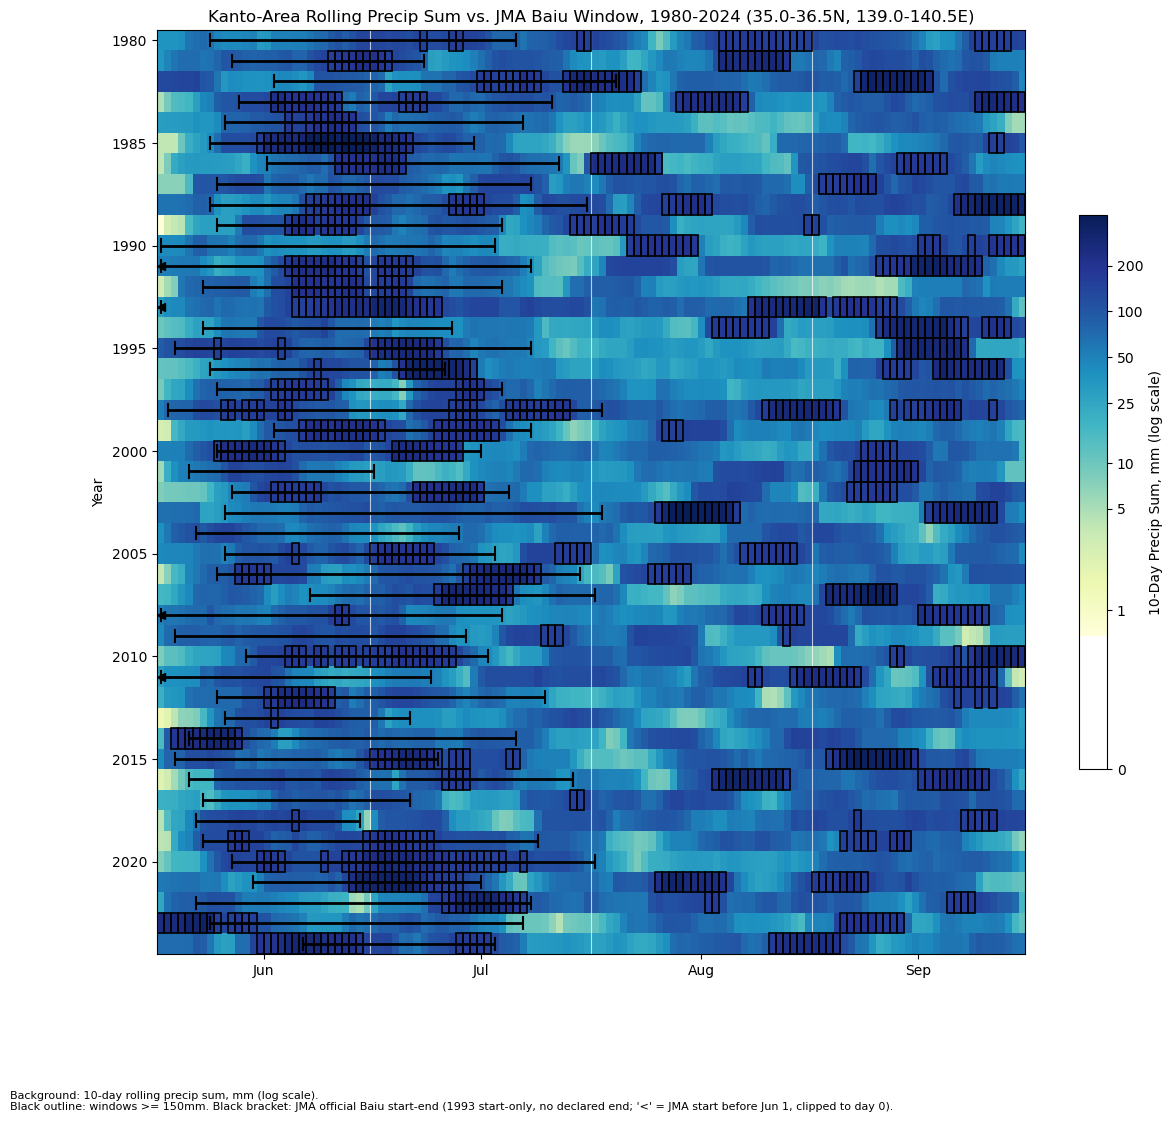

In [26]:
jma_baiu = pd.read_csv(
    _p / "data" / "jma" / "baiu_end_dates_1980_2025.csv",
    parse_dates=["baiu_start_date", "baiu_end_date"],
)
jma_baiu = jma_baiu[jma_baiu["year"].isin(years)]  # drop 2025, outside the ERA5-Land 1980-2024 record


def _col_for_date(date):
    # Clip late-May Baiu-start dates to day 0 (Jun 1) -- the grid only spans Jun-Sep
    if pd.isna(date):
        return None
    if date.month < 6:
        return 0
    return MONTH_OFFSET[date.month] + (date.day - 1)


fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(log_tp_rolled_grid, aspect="auto", cmap=PRECIP_CMAP, interpolation="nearest")

# Heavy-rain-spell threshold highlight, same as Fig 7-4
hot_rows, hot_cols = np.where(tp_rolled_grid >= th_precip_5day)
for r, c in zip(hot_rows, hot_cols):
    ax.add_patch(
        mpatches.Rectangle(
            (c - 0.5, r - 0.5), 1, 1, fill=False, edgecolor="black", linewidth=1.2, zorder=5
        )
    )

for _, jma_row in jma_baiu.iterrows():
    r = jma_row["year"] - years[0]
    start_col = _col_for_date(jma_row["baiu_start_date"])
    end_col = _col_for_date(jma_row["baiu_end_date"])
    if start_col is None:
        continue
    if pd.notna(jma_row["baiu_start_date"]) and jma_row["baiu_start_date"].month < 6:
        ax.plot(start_col, r, marker="<", color="black", markersize=6, zorder=6)
    if end_col is None:
        # No declared end date this year (e.g. 1993) -- mark the start only
        ax.plot(start_col, r, marker="|", color="black", markersize=10, markeredgewidth=1.5, zorder=6)
        continue
    ax.plot([start_col, end_col], [r, r], color="black", linewidth=2, solid_capstyle="butt", zorder=6)
    ax.plot([start_col, start_col], [r - 0.3, r + 0.3], color="black", linewidth=1.5, zorder=6)
    ax.plot([end_col, end_col], [r - 0.3, r + 0.3], color="black", linewidth=1.5, zorder=6)

ax.set_xticks([(month_bounds[i] + month_bounds[i + 1] - 1) / 2 for i in range(4)])
ax.set_xticklabels(month_names)
for x in month_bounds[1:-1]:
    ax.axvline(x - 0.5, color="white", linewidth=0.8, alpha=0.7)

ax.set_yticks(np.arange(0, len(years), 5))
ax.set_yticklabels(years[::5])
ax.set_ylabel("Year")
ax.set_title(
    f"Kanto-Area Rolling Precip Sum vs. JMA Baiu Window, 1980-2024 "
    f"({KANTO_LAT_MIN}-{KANTO_LAT_MAX}N, {KANTO_LON_MIN}-{KANTO_LON_MAX}E)",
    fontsize=12,
)
fig.text(
    0.02, -0.02,
    f"Background: {ROLL_WINDOW}-day rolling precip sum, mm (log scale). \n"
    f"Black outline: windows >= {th_precip_5day}mm. Black bracket: JMA official Baiu start-end "
    "(1993 start-only, no declared end; '<' = JMA start before Jun 1, clipped to day 0).",
    fontsize=8, ha="left",
)

tick_vals_mm = [0, 1, 5, 10, 25, 50, 100, 200]
cbar = fig.colorbar(im, ax=ax, label=f"{ROLL_WINDOW}-Day Precip Sum, mm (log scale)", shrink=0.6)
cbar.set_ticks(np.log10(np.array(tick_vals_mm) + 0.1))
cbar.set_ticklabels([str(v) for v in tick_vals_mm])

savefig(fig, section=7, fig_num=5, title="kanto_precip_calendar_with_jma_baiu_window")
plt.show()

**Observation:** The JMA-declared Baiu bracket generally bounds where the rolling-sum wet-spell clusters concentrate in June-July, holding up across several window/threshold choices tried (10-day and 14-day windows, 100-200mm thresholds) -- a reasonable visual cross-check that the ERA5-Land Kanto-mean signal tracks the officially declared window, though this is not a substitute for the point-by-point validation planned for notebook 03. Two more specific patterns stand out: (1) heavy-rain flags cluster disproportionately at or just past the bracket's *end* rather than spread evenly across it, consistent with Baiu's known tendency to close with an intense rain burst before the front retreats; (2) a separate cluster of heavy-rain flags appears in late August-September, entirely outside the JMA Baiu window -- presumably the distinct autumn rain/typhoon season, not Baiu itself. Both the density of flags and their spread beyond the bracket also look greater in the most recent ~5 years than earlier in the record, echoing the Section 5 R95p intensification finding -- though as with every hedged observation in this notebook, that's an eyeball impression on 45 years of data, not a tested trend.

**Important caveat:** JMA's official Baiu declaration is not based on precipitation alone -- it also incorporates persistent cloud cover and broader synoptic-pattern judgment, neither of which this dataset captures (ERA5-Land here provides only 2m temperature and precipitation). Some mismatch between the JMA bracket and the ERA5-Land wet-spell timing is therefore expected on methodological grounds, not necessarily an error in either the JMA declaration or the reanalysis data -- precipitation is one component of the Baiu signal, not the whole of it.

## 8. Spatial Extent of Extreme Heat (Prototype)

Sections 6-7 all reduce the Kanto grid to a single area-mean value per day, which can mask a sharp, spatially concentrated exceedance under a mild area average -- a day where a small hotspot pushes the mean up looks identical to a day where the whole box is uniformly hot, if their area-mean values happen to match. This section asks a different question: on any given day, what *fraction* of the valid (land) grid cells within the Kanto bbox actually exceed the hot-day threshold (`th_temp`, the same adjustable variable used for Fig 7-1's highlight)?

This is a prototype using max temp only, in the same year x day calendar layout as Section 7 (reusing `MONTH_OFFSET`, `month_bounds`, `month_names`, `years`, `th_temp` — no recomputation of the grid scaffolding). Extending the same idea to min-temp/tropical-night extent or precip extent is a natural next step if this proves useful, but is deliberately not built preemptively — Section 8 is kept as its own space for "how much area is affected" metrics, separate from the area-mean value calendars in Sections 1-7.

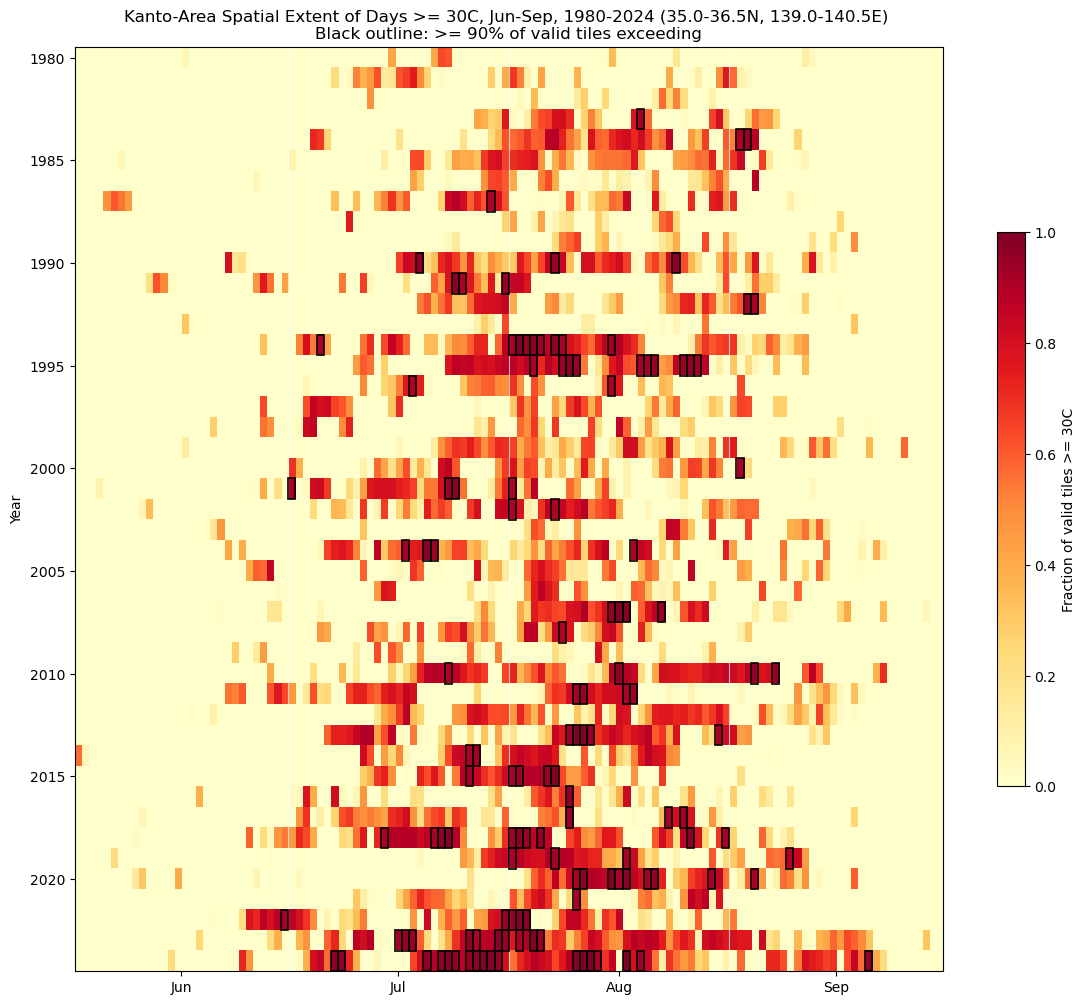

In [27]:
def kanto_exceed_fraction(da: xr.DataArray, threshold: float) -> xr.DataArray:
    """Fraction of valid (land) Kanto-bbox grid cells exceeding threshold, per timestep."""
    mask = (
        (da["latitude"] >= KANTO_LAT_MIN)
        & (da["latitude"] <= KANTO_LAT_MAX)
        & (da["longitude"] >= KANTO_LON_MIN)
        & (da["longitude"] <= KANTO_LON_MAX)
    )
    bbox = da.where(mask)
    valid_count = bbox.notnull().sum(dim=["latitude", "longitude"])
    exceed_count = (bbox >= threshold).sum(dim=["latitude", "longitude"])
    return exceed_count / valid_count

# th and window knobs for this block
th_temp = 30

tmax_exceed_frac = kanto_exceed_fraction(daily_tmax, th_temp)
tmax_exceed_season = tmax_exceed_frac.sel(
    valid_time=tmax_exceed_frac["valid_time"].dt.month.isin([6, 7, 8, 9])
)

ex_months = tmax_exceed_season["valid_time"].dt.month.values
ex_days = tmax_exceed_season["valid_time"].dt.day.values
ex_obs_years = tmax_exceed_season["valid_time"].dt.year.values

ex_col_idx = np.array([MONTH_OFFSET[m] + (d - 1) for m, d in zip(ex_months, ex_days)])
ex_row_idx = ex_obs_years - years[0]

exceed_grid = np.full((len(years), N_DAYS), np.nan)
exceed_grid[ex_row_idx, ex_col_idx] = tmax_exceed_season.values

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(exceed_grid, aspect="auto", cmap="YlOrRd", interpolation="nearest", vmin=0, vmax=1)

# Highlight days where a large share of the box is affected -- independent of th_temp above
th_extent = 0.90
hot_rows, hot_cols = np.where(exceed_grid >= th_extent)
for r, c in zip(hot_rows, hot_cols):
    ax.add_patch(
        mpatches.Rectangle(
            (c - 0.5, r - 0.5), 1, 1, fill=False, edgecolor="black", linewidth=1.2, zorder=5
        )
    )

ax.set_xticks([(month_bounds[i] + month_bounds[i + 1] - 1) / 2 for i in range(4)])
ax.set_xticklabels(month_names)
for x in month_bounds[1:-1]:
    ax.axvline(x - 0.5, color="white", linewidth=0.8, alpha=0.7)

ax.set_yticks(np.arange(0, len(years), 5))
ax.set_yticklabels(years[::5])
ax.set_ylabel("Year")
ax.set_title(
    f"Kanto-Area Spatial Extent of Days >= {th_temp}C, Jun-Sep, 1980-2024 "
    f"({KANTO_LAT_MIN}-{KANTO_LAT_MAX}N, {KANTO_LON_MIN}-{KANTO_LON_MAX}E) \n"
    f"Black outline: >= {int(th_extent * 100)}% of valid tiles exceeding"
)
fig.colorbar(im, ax=ax, label=f"Fraction of valid tiles >= {th_temp}C", shrink=0.6)
savefig(fig, section=8, fig_num=1, title="kanto_tmax_exceedance_extent_calendar_heatmap")
plt.show()

**Observation:** The exceedance-fraction view surfaces a pattern the area-mean calendars (Sections 6-7) don't show as clearly: essentially no wide-area hot days before the mid-1980s, then an increasing frequency of days where a large share of the Kanto box crosses `th_temp` simultaneously.

Two things stand out in particular. First, **the 1994-1995 heatwave still stands out** even in this view -- it produces the densest, most spatially saturated cluster in the pre-2010 record, with several weeks where close to 100% of valid tiles exceed `th_temp` at once. This reinforces (from a different angle) the "hot-side wiggle" already flagged in Section 6: 1994-95 was a genuine, areally extreme event, not just a point-reading spike.

Second, **stripping that single event out, the widening of wide-area heat coverage through the 2020s is stark.** The `th_extent >= 0.5` outline is scattered and intermittent through the 1990s-2010s, but by 2022-2024 it forms a long, close-to-continuous stretch spanning nearly all of July -- the longest sustained run of wide-area hot days anywhere in the 45-year record, more continuous (if not more intense at its single hottest moment) than 1994-95. Read together, this suggests two distinct extreme-heat "modes" in this record: a rare, very intense areal spike (1994-95) versus a newer, more sustained pattern of wide-area heat becoming close to the summer norm (early 2020s) -- worth keeping distinct rather than treating recent summers as "bigger versions of 1994." As with every hedged observation in this notebook, this is a descriptive read of one bounding box over 45 years; formal trend/changepoint testing (Pettitt, GAM) belongs in the RQ1 statistical notebook, not here.

### Fig 8-2: Spatial Extent of Tropical Nights

Same exceedance-fraction idea as Fig 8-1 (reusing the `kanto_exceed_fraction` helper, no recomputation), now for daily-min temp instead of max — the spatial-extent analog of the Section 4/Fig 7-2 tropical-night signal. `th_temp_min` and `th_extent` are set fresh in this cell (separate from Fig 7-2's and Fig 8-1's variables of the same name, which keep whatever they were left at).

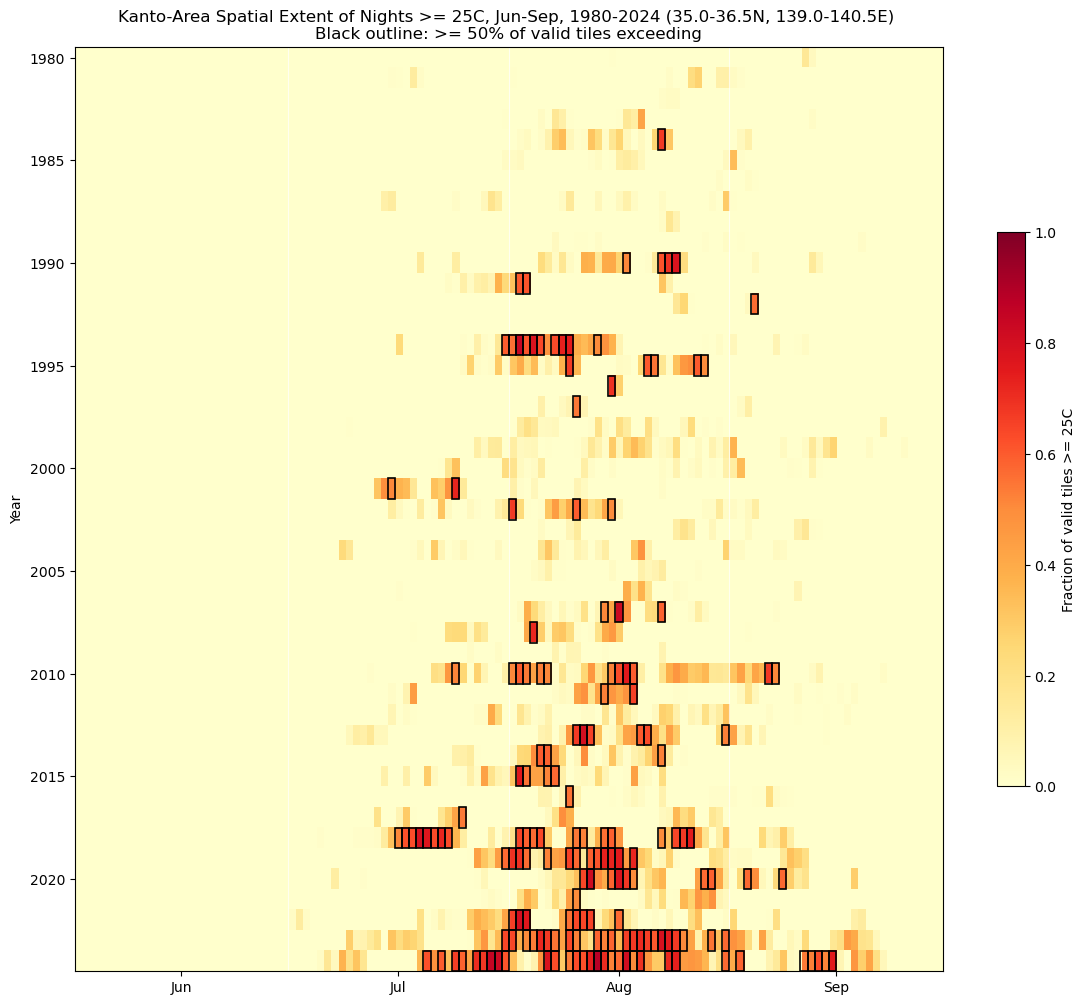

In [28]:
th_temp_min = 25  # tropical-night threshold, matches Fig 7-2 -- separate variable, local to this cell

tmin_exceed_frac = kanto_exceed_fraction(daily_tmin, th_temp_min)
tmin_exceed_season = tmin_exceed_frac.sel(
    valid_time=tmin_exceed_frac["valid_time"].dt.month.isin([6, 7, 8, 9])
)

tn_months = tmin_exceed_season["valid_time"].dt.month.values
tn_days = tmin_exceed_season["valid_time"].dt.day.values
tn_obs_years = tmin_exceed_season["valid_time"].dt.year.values

tn_col_idx = np.array([MONTH_OFFSET[m] + (d - 1) for m, d in zip(tn_months, tn_days)])
tn_row_idx = tn_obs_years - years[0]

exceed_grid_tmin = np.full((len(years), N_DAYS), np.nan)
exceed_grid_tmin[tn_row_idx, tn_col_idx] = tmin_exceed_season.values

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(exceed_grid_tmin, aspect="auto", cmap="YlOrRd", interpolation="nearest", vmin=0, vmax=1)

# Highlight days where a large share of the box is affected -- fresh th_extent, local to this cell
th_extent = 0.5
hot_rows, hot_cols = np.where(exceed_grid_tmin >= th_extent)
for r, c in zip(hot_rows, hot_cols):
    ax.add_patch(
        mpatches.Rectangle(
            (c - 0.5, r - 0.5), 1, 1, fill=False, edgecolor="black", linewidth=1.2, zorder=5
        )
    )

ax.set_xticks([(month_bounds[i] + month_bounds[i + 1] - 1) / 2 for i in range(4)])
ax.set_xticklabels(month_names)
for x in month_bounds[1:-1]:
    ax.axvline(x - 0.5, color="white", linewidth=0.8, alpha=0.7)

ax.set_yticks(np.arange(0, len(years), 5))
ax.set_yticklabels(years[::5])
ax.set_ylabel("Year")
ax.set_title(
    f"Kanto-Area Spatial Extent of Nights >= {th_temp_min}C, Jun-Sep, 1980-2024 "
    f"({KANTO_LAT_MIN}-{KANTO_LAT_MAX}N, {KANTO_LON_MIN}-{KANTO_LON_MAX}E) \n"
    f"Black outline: >= {int(th_extent * 100)}% of valid tiles exceeding"
)
fig.colorbar(im, ax=ax, label=f"Fraction of valid tiles >= {th_temp_min}C", shrink=0.6)
savefig(fig, section=8, fig_num=2, title="kanto_tmin_exceedance_extent_calendar_heatmap")
plt.show()

### Fig 8-3: Spatial Extent of Heavy Rain Days

Same idea again, now for daily total precipitation — raw daily values per tile (not the rolling-sum basis from Fig 7-4/7-5), consistent with Fig 8-1's approach so all three Section 8 figures use the same simple exceedance-fraction definition. `th_precip` and `th_extent` are set fresh in this cell, separate from the same-named variables elsewhere in the notebook.

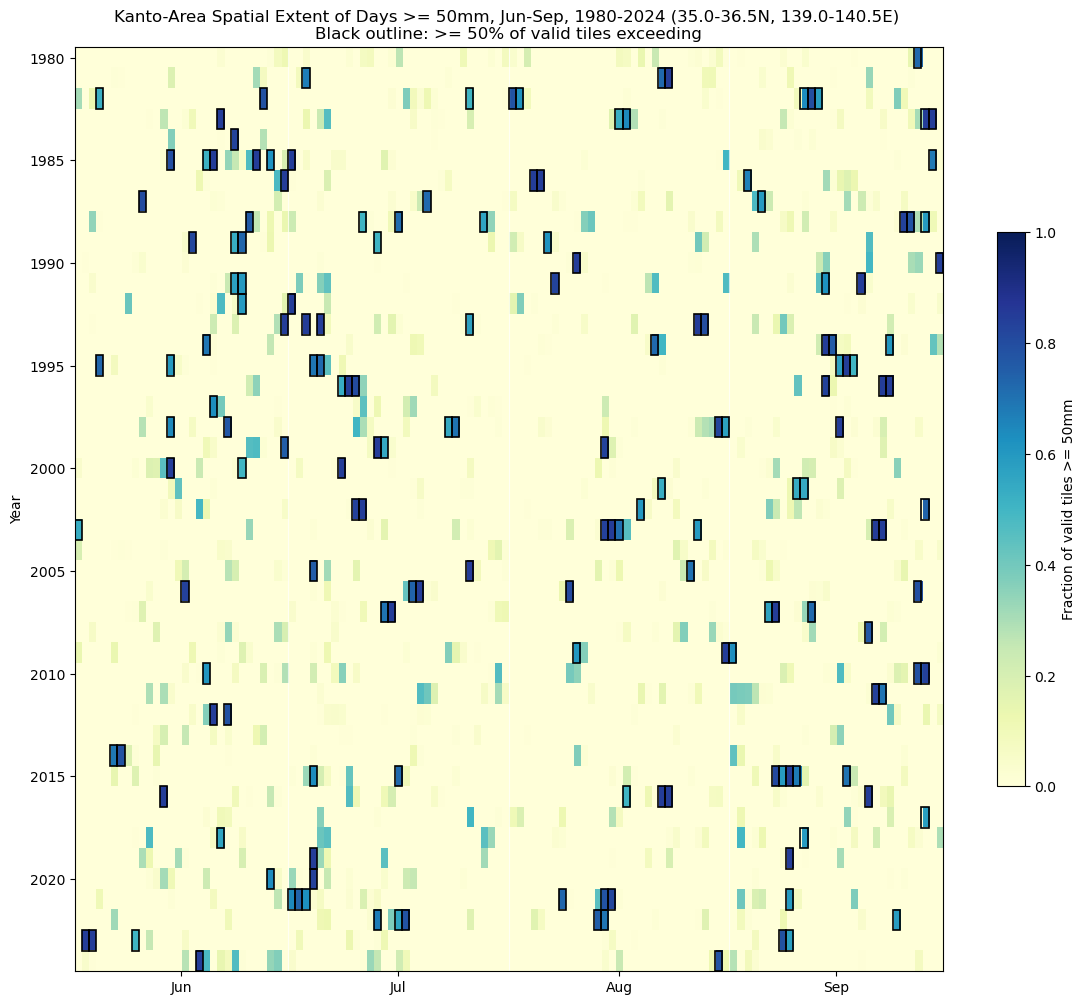

In [29]:
th_precip = 50  # heavy-rain threshold, matches Fig 7-3 -- separate variable, local to this cell

tp_exceed_frac = kanto_exceed_fraction(daily_tp, th_precip)
tp_exceed_season = tp_exceed_frac.sel(
    valid_time=tp_exceed_frac["valid_time"].dt.month.isin([6, 7, 8, 9])
)

tpe_months = tp_exceed_season["valid_time"].dt.month.values
tpe_days = tp_exceed_season["valid_time"].dt.day.values
tpe_obs_years = tp_exceed_season["valid_time"].dt.year.values

tpe_col_idx = np.array([MONTH_OFFSET[m] + (d - 1) for m, d in zip(tpe_months, tpe_days)])
tpe_row_idx = tpe_obs_years - years[0]

exceed_grid_tp = np.full((len(years), N_DAYS), np.nan)
exceed_grid_tp[tpe_row_idx, tpe_col_idx] = tp_exceed_season.values

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(exceed_grid_tp, aspect="auto", cmap=PRECIP_CMAP, interpolation="nearest", vmin=0, vmax=1)

# Highlight days where a large share of the box is affected -- fresh th_extent, local to this cell
th_extent = 0.5
hot_rows, hot_cols = np.where(exceed_grid_tp >= th_extent)
for r, c in zip(hot_rows, hot_cols):
    ax.add_patch(
        mpatches.Rectangle(
            (c - 0.5, r - 0.5), 1, 1, fill=False, edgecolor="black", linewidth=1.2, zorder=5
        )
    )

ax.set_xticks([(month_bounds[i] + month_bounds[i + 1] - 1) / 2 for i in range(4)])
ax.set_xticklabels(month_names)
for x in month_bounds[1:-1]:
    ax.axvline(x - 0.5, color="white", linewidth=0.8, alpha=0.7)

ax.set_yticks(np.arange(0, len(years), 5))
ax.set_yticklabels(years[::5])
ax.set_ylabel("Year")
ax.set_title(
    f"Kanto-Area Spatial Extent of Days >= {th_precip}mm, Jun-Sep, 1980-2024 "
    f"({KANTO_LAT_MIN}-{KANTO_LAT_MAX}N, {KANTO_LON_MIN}-{KANTO_LON_MAX}E) \n"
    f"Black outline: >= {int(th_extent * 100)}% of valid tiles exceeding"
)
fig.colorbar(im, ax=ax, label=f"Fraction of valid tiles >= {th_precip}mm", shrink=0.6)
savefig(fig, section=8, fig_num=3, title="kanto_precip_exceedance_extent_calendar_heatmap")
plt.show()